# import Statments

In [1]:
import pandas as pd                    #  data handling
import numpy as np                     #  numerical operations
import matplotlib.pyplot as plt        #  plotting
import seaborn as sns                  #  static data visualization
import plotly.express as px            #  interactive plots
import plotly.graph_objects as go
from scipy.signal import butter, filtfilt, iirnotch
import math
from scipy.stats import zscore
from scipy.stats import median_abs_deviation
import missingno as msno
import re
from itertools import product
from IPython.display import display
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, average_precision_score,
    classification_report, confusion_matrix
)







# Load Data

In [2]:
path = '/content/EMG Data 3. .xlsx'
EMG_df = pd.read_excel(path)

EMG_df.head()

,patient_id,age,sex,side,dominant Hand,Nerve,MUAP Amplitude uV,MUAP Ration ms,MUAP Polyphasia Percent,Firing Rate hz,Diagnosis Severity
0,1.0,69,F,Left,Right,Median,751.0,10.0,4.7,12.8,Normal
1,2.0,26,F,Right,Right,Ulnar,2798.0,13.4,23.9,12.2,Moderate
2,3.0,47,F,Right,Right,Ulnar,946.0,9.8,5.8,8.9,Normal
3,4.0,25,M,Left,Right,Median,1217.0,8.7,14.2,20.1,Normal
4,5.0,41,F,Right,Right,Median,2763.0,16.3,22.9,17.9,Moderate


# EDA

## Data Structure Understanding

In [3]:
print("Shape of the dataset:", EMG_df.shape)

Shape of the dataset: (912, 11)


In [4]:
print("Columns:", EMG_df.columns)

Columns: Index(['patient_id', 'age', 'sex', 'side', 'dominant Hand', 'Nerve',
       'MUAP Amplitude uV', 'MUAP Ration ms', 'MUAP Polyphasia Percent',
       'Firing Rate hz', 'Diagnosis Severity'],
      dtype='object')


In [5]:
print("\nBasic statistics:\n", EMG_df.describe())


Basic statistics:
         patient_id         age  MUAP Amplitude uV  MUAP Ration ms  \
count   912.000000  912.000000         912.000000      912.000000   
mean    492.031001   49.127193         995.497697       10.884868   
std     295.707016   17.918625         614.454031        2.869307   
min       1.000000   18.000000         150.000000        3.000000   
25%     228.750000   34.000000         630.675000        9.000000   
50%     486.575758   49.000000         806.150000       10.600000   
75%     748.833333   65.000000        1145.375000       12.700000   
max    1011.090909   79.000000        4408.000000       21.300000   

       MUAP Polyphasia Percent  Firing Rate hz  
count               912.000000      912.000000  
mean                 20.536294       12.705921  
std                  12.717719        4.032833  
min                   0.000000        3.000000  
25%                  10.150000        9.900000  
50%                  19.000000       12.600000  
75%            

In [6]:
# Data Info + Memory Usage

EMG_df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   patient_id               912 non-null    float64
 1   age                      912 non-null    int64  
 2   sex                      912 non-null    object 
 3   side                     912 non-null    object 
 4   dominant Hand            912 non-null    object 
 5   Nerve                    912 non-null    object 
 6   MUAP Amplitude uV        912 non-null    float64
 7   MUAP Ration ms           912 non-null    float64
 8   MUAP Polyphasia Percent  912 non-null    float64
 9   Firing Rate hz           912 non-null    float64
 10  Diagnosis Severity       912 non-null    object 
dtypes: float64(5), int64(1), object(5)
memory usage: 282.9 KB


In [7]:
#Count numeric & categorical features

# Select numeric & categorical features
numeric_features = EMG_df.select_dtypes(include=['int64', 'float64']).drop(columns=['patient_id'])
categorical_features = EMG_df.select_dtypes(include=['object', 'category'])

# column counts
print("Number of Numeric features:", len(numeric_features.columns))
print("Number of Categorical features:", len(categorical_features.columns))

# column names
print("\nNumeric feature:")
print(list(numeric_features.columns))

print("\nCategorical feature:")
print(list(categorical_features.columns))

Number of Numeric features: 5
Number of Categorical features: 5

Numeric feature:
['age', 'MUAP Amplitude uV', 'MUAP Ration ms', 'MUAP Polyphasia Percent', 'Firing Rate hz']

Categorical feature:
['sex', 'side', 'dominant Hand', 'Nerve', 'Diagnosis Severity']


## Descriptive Summary Statistics

In [8]:
# Summary stats for all numeric features

numeric_cols = EMG_df.select_dtypes(include=['float64', 'int64']).columns
numeric_cols = numeric_cols.drop('patient_id')

EMG_df[numeric_cols].describe().T  # Transpose for readability

,count,mean,std,min,25%,50%,75%,max
age,912.0,49.127193,17.918625,18.0,34.000,49.00,65.000,79.0
MUAP Amplitude uV,912.0,995.497697,614.454031,150.0,630.675,806.15,1145.375,4408.0
MUAP Ration ms,912.0,10.884868,2.869307,3.0,9.000,10.60,12.700,21.3
MUAP Polyphasia Percent,912.0,20.536294,12.717719,0.0,10.150,19.00,27.625,65.0
Firing Rate hz,912.0,12.705921,4.032833,3.0,9.900,12.60,15.300,26.6


In [9]:
print( type(numeric_features))
print( type(numeric_cols) )

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.indexes.base.Index'>


## Target Label Distribution

In [10]:
print("Severity distribution:")
print(EMG_df['Diagnosis Severity'].value_counts())

Severity distribution:
Diagnosis Severity
Normal      353
Mild        262
Moderate    195
Severe      102
Name: count, dtype: int64


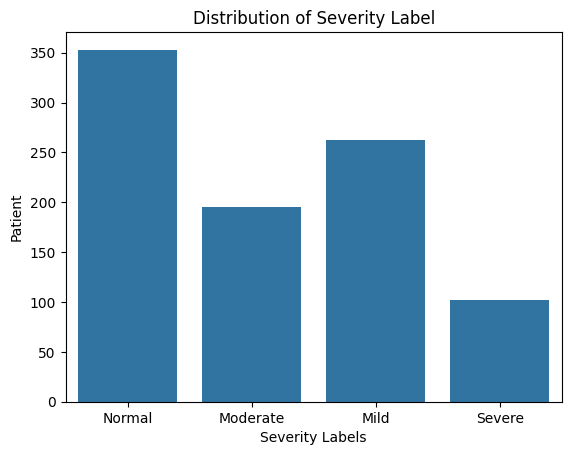

In [11]:
sns.countplot(data=EMG_df, x='Diagnosis Severity')

plt.title('Distribution of Severity Label')
plt.xlabel("Severity Labels")
plt.ylabel("Patient")
plt.show()

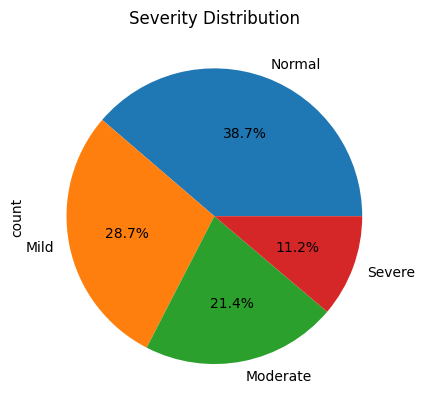

In [12]:
EMG_df['Diagnosis Severity'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Severity Distribution")
plt.show()

## Correlation Analysis

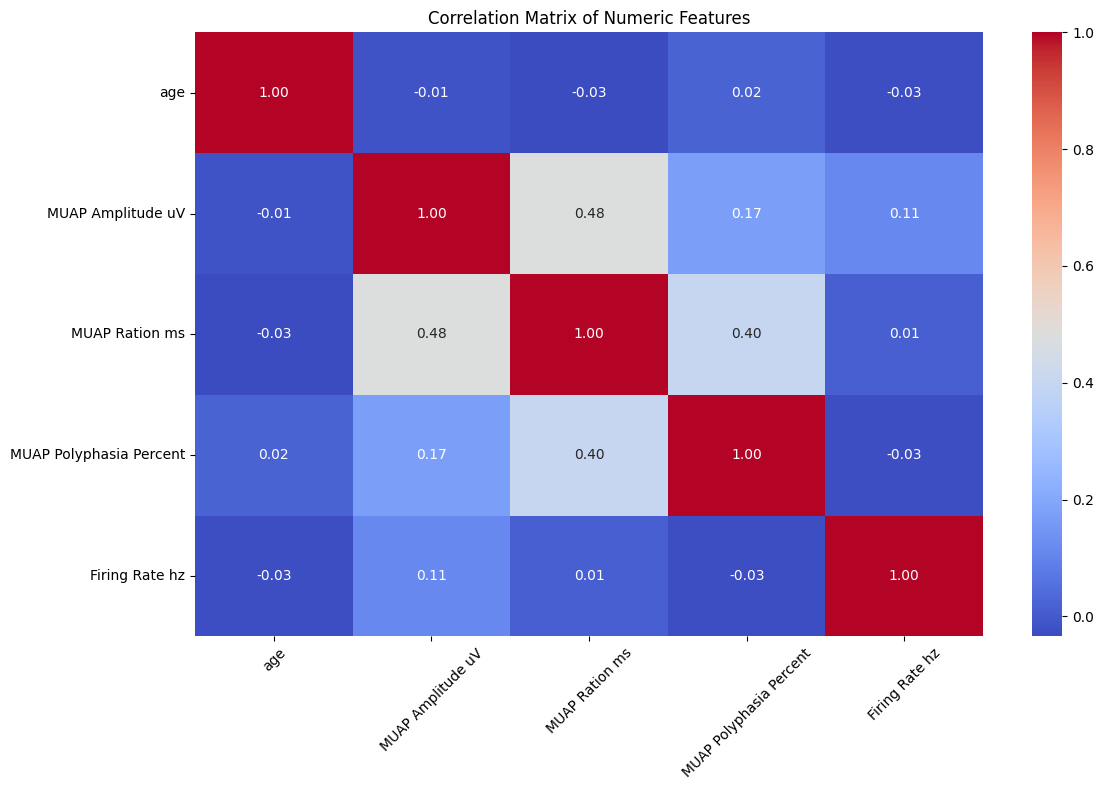

In [13]:
# Correlation matrix to detect collinear features

corr = EMG_df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.title("Correlation Matrix of Numeric Features")
plt.tight_layout()
plt.show()

## Distribution of Each EMG Feature

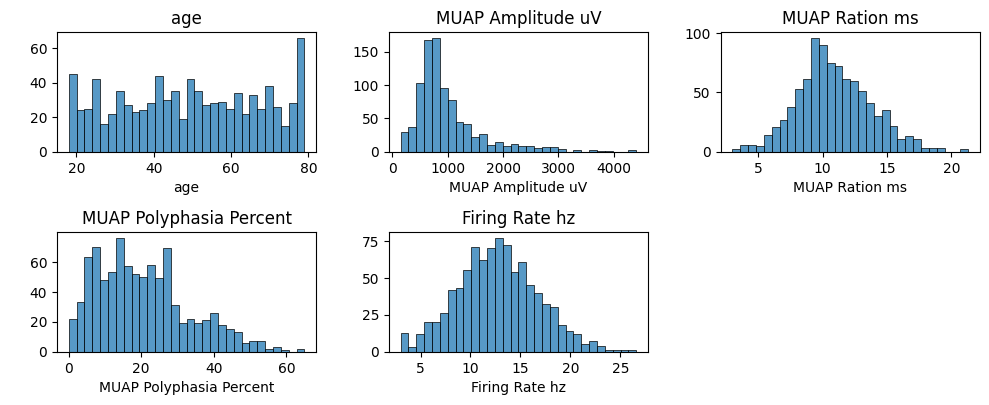

In [14]:
# number of charts per row
cols = 3

# round up the number of rows ; Ensures enough rows to display all features.
rows = math.ceil( len(numeric_features) / cols)

# Create Creates a new figure for all subplots ( witdh,height  )
plt.figure(figsize=(10, rows * 2))


for i, col in enumerate(numeric_features, 1):
    #Creates the i-th subplot in a grid of rows × cols.
    plt.subplot(rows, cols, i)

    # draws histogram + dropna() removes missing values before plottin + splits the data range into 30 buckets +  no density curve
    sns.histplot(EMG_df[col].dropna(), bins=30, kde=False)
    plt.title(f'{col}')
    plt.xlabel(col, fontsize=10)
    plt.ylabel(' ', fontsize=10)

plt.tight_layout()
plt.show()

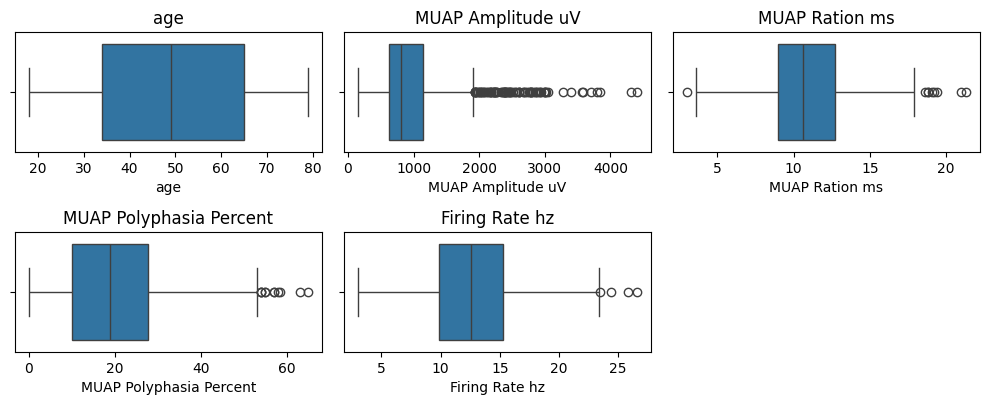

In [15]:
#  Boxplot by Nerve or Severity

plt.figure(figsize=(10, rows * 2))

for i, col in enumerate(numeric_features, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(x=EMG_df[col].dropna())
    plt.title(f'{col}')
    plt.xlabel(col, fontsize=10)

plt.tight_layout()
plt.show()

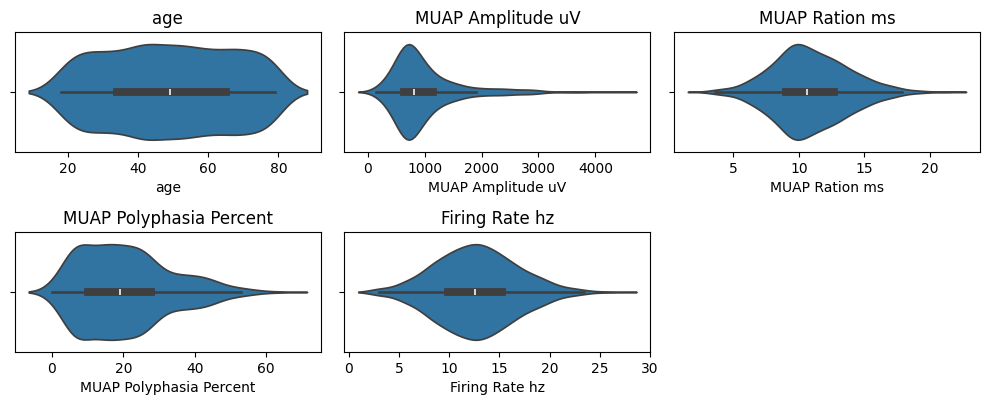

In [16]:
#Violin Plot
plt.figure(figsize=(10, rows * 2))

for i, col in enumerate(numeric_features, 1):
    plt.subplot(rows, cols, i)
    sns.violinplot(x=EMG_df[col].dropna())
    plt.title(f'{col}')
    plt.xlabel(col, fontsize=10)

plt.tight_layout()
plt.show()

### Catagorical Features Distribution

/tmp/ipykernel_6770/1258442633.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=EMG_df, x=col, palette='Set2')
/tmp/ipykernel_6770/1258442633.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=EMG_df, x=col, palette='Set2')
/tmp/ipykernel_6770/1258442633.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=EMG_df, x=col, palette='Set2')
/tmp/ipykernel_6770/1258442633.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and s

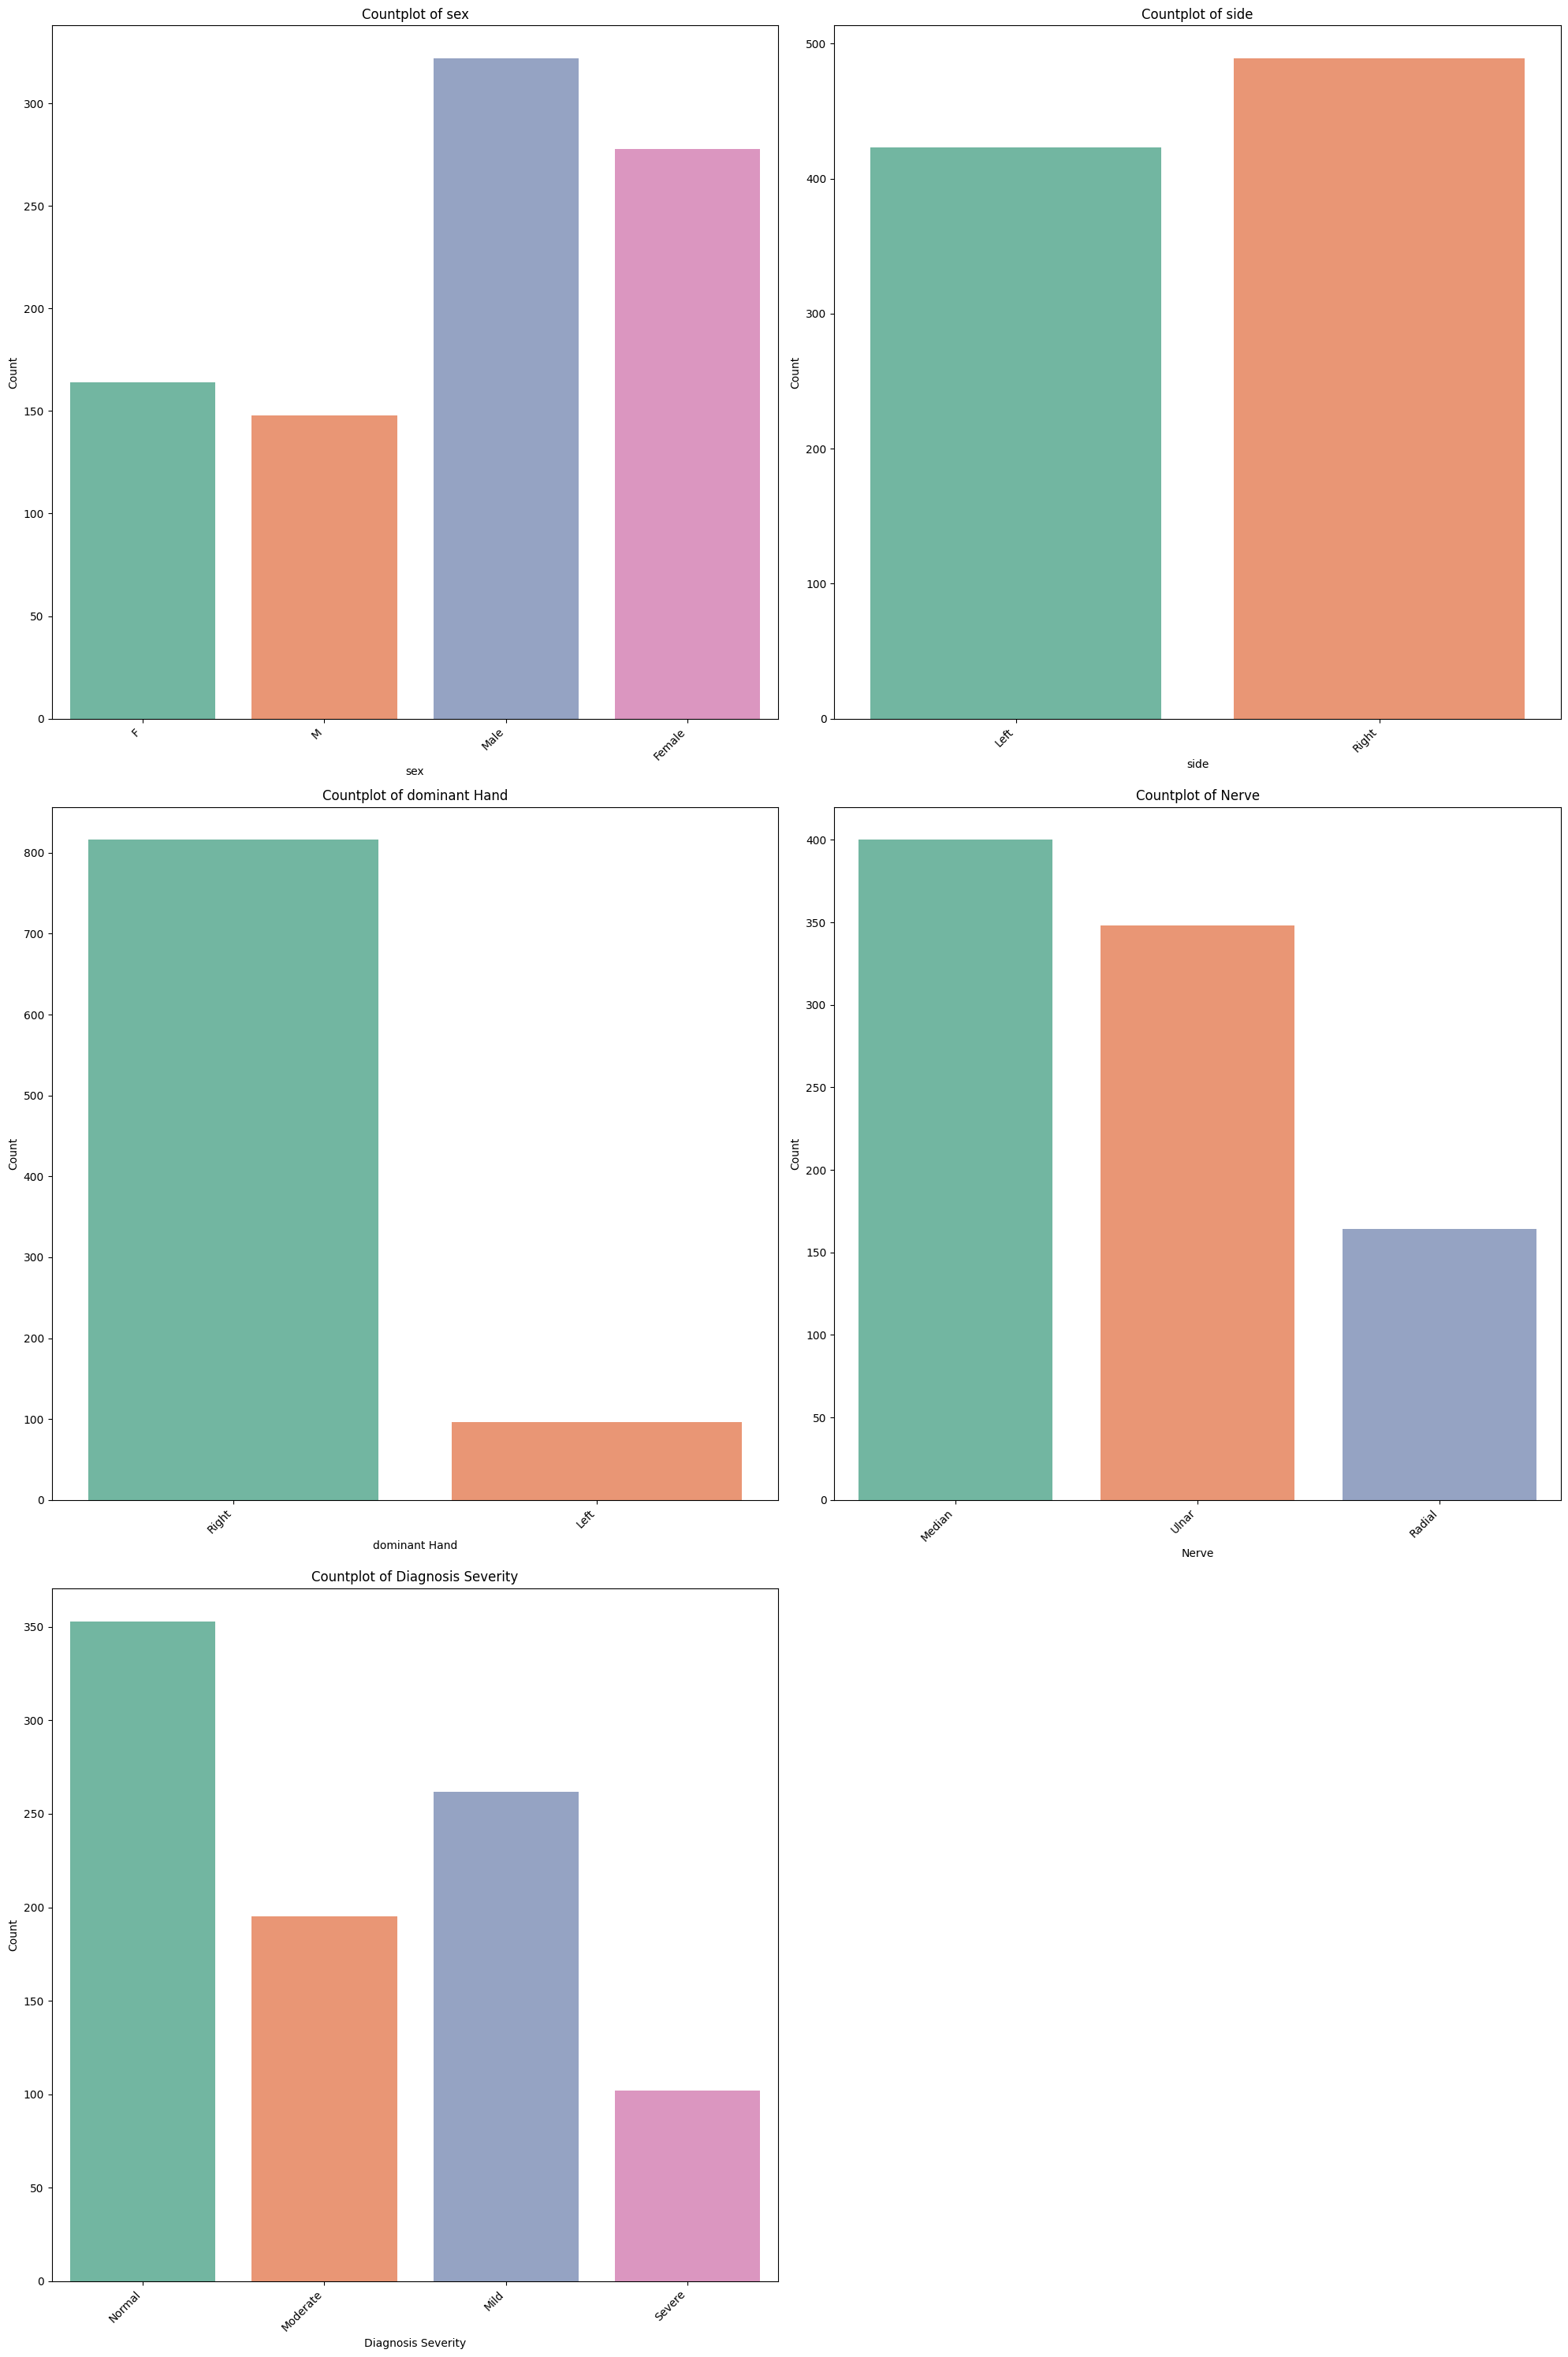

In [17]:
# Count Plot

# Select categorical columns
categorical_cols = EMG_df.select_dtypes(include=['object', 'category']).columns

# Number of categorical features
n_cat = len(categorical_cols)

# Layout
cols = 2   # number of plots per row
rows = math.ceil(n_cat / cols)

# Create figure
plt.figure(figsize=(20, rows * 10))

# Loop for subplots
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(rows, cols, i)
    sns.countplot(data=EMG_df, x=col, palette='Set2')
    plt.title(f'Countplot of {col}', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

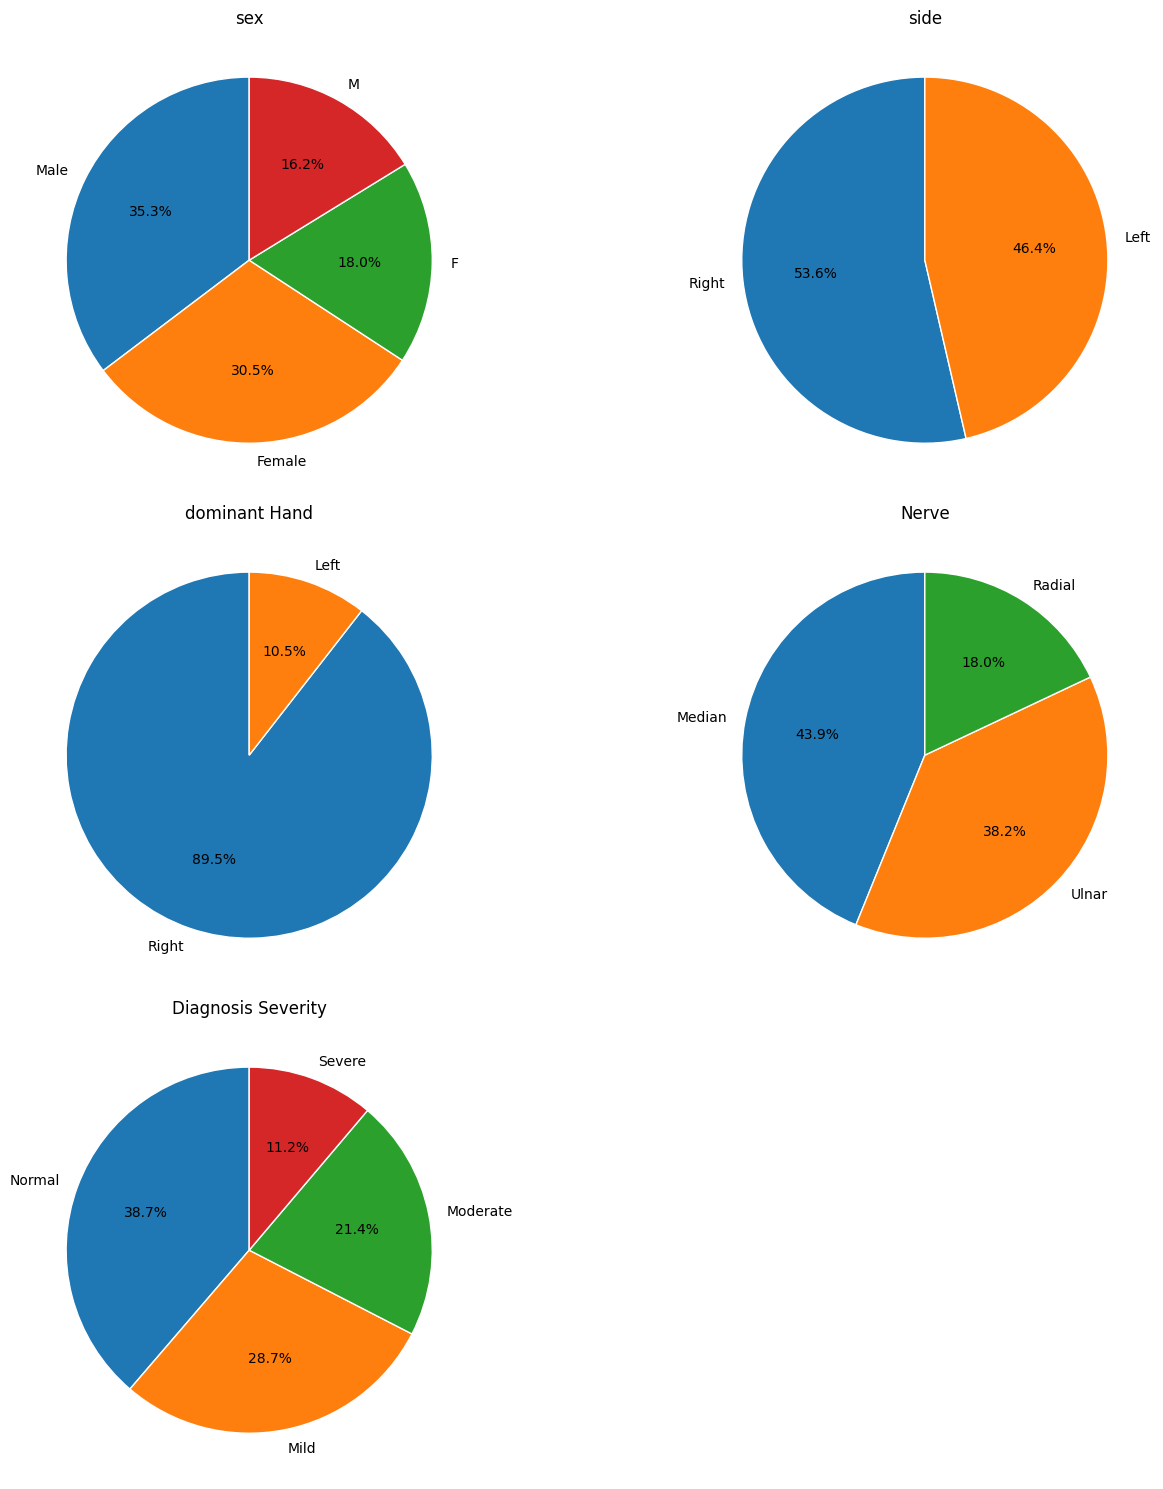

In [18]:
# Pie chart

# Select categorical columns
categorical_cols = EMG_df.select_dtypes(include=['object', 'category']).columns

# Number of categorical features
n_cat = len(categorical_cols)

# Subplot layout
cols = 2
rows = math.ceil(n_cat / cols)

# Create the figure
plt.figure(figsize=(14, rows * 5))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(rows, cols, i)

    # Get counts
    data = EMG_df[col].value_counts()

    # Pie chart
    plt.pie(
        data.values,
        labels=data.index,
        autopct='%1.1f%%',
        startangle=90,
        textprops={'fontsize': 10},
        wedgeprops={'linewidth': 1, 'edgecolor': 'white'}
    )

    plt.title(f'{col}', fontsize=12)

plt.tight_layout()
plt.show()

## Missing Values

In [19]:
print("Missing values per column:\n", EMG_df.isnull().sum()) #Nan None

Missing values per column:
 patient_id                 0
age                        0
sex                        0
side                       0
dominant Hand              0
Nerve                      0
MUAP Amplitude uV          0
MUAP Ration ms             0
MUAP Polyphasia Percent    0
Firing Rate hz             0
Diagnosis Severity         0
dtype: int64


## Duplicates Recoreds


In [20]:
dup_rows = EMG_df.duplicated().sum()
print("\nNumber of Fully Duplicated rows:", dup_rows)


Number of Fully Duplicated rows: 0


## Detecting Messy Format

In [21]:
# Detect Non-Numeric Characters Inside Numeric Columns

for col in EMG_df.select_dtypes(include='object'):
    # Check if column is supposed to be numeric
    try:
        EMG_df[col].astype(float)
        print(f"POSSIBLE WRONG FORMAT → {col}: contains numeric-like strings")
    except:
        pass


In [22]:
# Detect Leading / Trailing Spaces

for col in EMG_df.select_dtypes(include='object'):
    EMG_df[col] = EMG_df[col].astype(str)
    if EMG_df[col].str.contains(r'^\s+|\s+$').any():
        print(f"WARNING: Spaces in {col}")

In [23]:
# Detect Mixed Formats

for col in EMG_df.select_dtypes(include='object'):
    print(f"\nUnique values in {col}:")
    print(EMG_df[col].unique())


Unique values in sex:
['F' 'M' 'Male' 'Female']

Unique values in side:
['Left' 'Right']

Unique values in dominant Hand:
['Right' 'Left']

Unique values in Nerve:
['Median' 'Ulnar' 'Radial']

Unique values in Diagnosis Severity:
['Normal' 'Moderate' 'Mild' 'Severe']


In [24]:
# Detect Unexpected / Invalid Categories

for col in EMG_df.select_dtypes(include='object'):
    print(f"\n{col} → unique values:")
    print(EMG_df[col].value_counts(dropna=False))


sex → unique values:
sex
Male      322
Female    278
F         164
M         148
Name: count, dtype: int64

side → unique values:
side
Right    489
Left     423
Name: count, dtype: int64

dominant Hand → unique values:
dominant Hand
Right    816
Left      96
Name: count, dtype: int64

Nerve → unique values:
Nerve
Median    400
Ulnar     348
Radial    164
Name: count, dtype: int64

Diagnosis Severity → unique values:
Diagnosis Severity
Normal      353
Mild        262
Moderate    195
Severe      102
Name: count, dtype: int64


In [25]:
# Detect Columns with Mixed Types

for col in EMG_df.columns:
    types = EMG_df[col].apply(type).value_counts()
    if len(types) > 1:
        print(f"Mixed types in {col}: {types}")

In [26]:
# Detect Symbols or Patterns in Categorical Columns

import re

for col in EMG_df.select_dtypes(include='object'):
    if EMG_df[col].str.contains(r'\(|\)|\+|\-').any():
        print(f"Possible encoded scale in {col}")

## Detecting Outliers

### IQR

In [27]:
'''
  - Fourmla:
        IQR = Q3 − Q1
        [Q1−1.5× IQR , Q3+1.5×IQR]
'''

Q1 = EMG_df[numeric_cols].quantile(0.25)
Q3 = EMG_df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Boolean mask of outliers (True = outlier)
outlier_mask = (EMG_df[numeric_cols] < lower_bound) | (EMG_df[numeric_cols] > upper_bound)

# Number of rows with at least one outlier
print("IQR Outlier Rows:", outlier_mask.any(axis=1).sum())

# List rows + feature names
for idx in outlier_mask.any(axis=1).index[outlier_mask.any(axis=1)]:
    feats = list(outlier_mask.columns[outlier_mask.loc[idx]])
    print(f"Row {idx}: {feats}")

IQR Outlier Rows: 95
Row 1: ['MUAP Amplitude uV']
Row 4: ['MUAP Amplitude uV']
Row 12: ['MUAP Amplitude uV']
Row 14: ['MUAP Amplitude uV']
Row 20: ['MUAP Amplitude uV']
Row 24: ['MUAP Amplitude uV']
Row 29: ['MUAP Amplitude uV']
Row 34: ['MUAP Amplitude uV']
Row 35: ['MUAP Amplitude uV', 'MUAP Polyphasia Percent']
Row 42: ['MUAP Amplitude uV']
Row 43: ['MUAP Amplitude uV']
Row 45: ['MUAP Amplitude uV', 'Firing Rate hz']
Row 48: ['MUAP Amplitude uV']
Row 50: ['MUAP Amplitude uV']
Row 51: ['MUAP Amplitude uV']
Row 55: ['MUAP Amplitude uV', 'Firing Rate hz']
Row 59: ['MUAP Amplitude uV']
Row 66: ['MUAP Amplitude uV']
Row 74: ['MUAP Amplitude uV']
Row 84: ['MUAP Amplitude uV']
Row 85: ['MUAP Amplitude uV']
Row 90: ['MUAP Amplitude uV']
Row 91: ['MUAP Amplitude uV']
Row 94: ['MUAP Amplitude uV']
Row 95: ['MUAP Amplitude uV']
Row 96: ['MUAP Amplitude uV', 'MUAP Ration ms']
Row 100: ['MUAP Amplitude uV']
Row 101: ['MUAP Amplitude uV']
Row 106: ['MUAP Amplitude uV']
Row 109: ['MUAP Amplitude u

### MAD:  Median Absolute Deviation

In [28]:
'''
  MAD: Median Absolute Deviation (Robust Z-score)

  Why MAD?
  - Z-score uses mean and std → very sensitive to outliers
  - MAD uses median → resistant to extreme values

  - formula:
       Z_robust = 0.6745 * (x - median) / MAD

  - Outlier If:
       |Z_robust| > threshold

  - Common threshold = 3.5 (more robust than Z-score=3)
'''

threshold = 3.5

# Compute median and MAD per numeric feature
median_vals = EMG_df[numeric_cols].median()
mad_vals = EMG_df[numeric_cols].apply(median_abs_deviation)

# Smoothing: Avoid division by zero by replacing MAD=0 with a tiny value
mad_vals = mad_vals.replace(0, 1e-9)

# Compute Robust Z-score
df_mad = 0.6745 * (EMG_df[numeric_cols] - median_vals) / mad_vals

# Boolean mask of outliers
outlier_flags = df_mad.abs() > threshold

# Count outliers per row
outlier_mask = outlier_flags.sum(axis=1)


# Results
print(f"Rows with > {threshold} MAD deviations:", (outlier_mask > 0).sum())
print("\n=== Outlier Rows and Feature Names ===\n")

for idx, count in outlier_mask[outlier_mask > 0].items():
    features_with_outliers = list(outlier_flags.columns[outlier_flags.loc[idx]])
    print(f"Row {idx}: {features_with_outliers}")

Rows with > 3.5 MAD deviations: 75

=== Outlier Rows and Feature Names ===

Row 1: ['MUAP Amplitude uV']
Row 4: ['MUAP Amplitude uV']
Row 12: ['MUAP Amplitude uV']
Row 14: ['MUAP Amplitude uV']
Row 20: ['MUAP Amplitude uV']
Row 24: ['MUAP Amplitude uV']
Row 29: ['MUAP Amplitude uV']
Row 35: ['MUAP Amplitude uV']
Row 42: ['MUAP Amplitude uV']
Row 43: ['MUAP Amplitude uV']
Row 45: ['MUAP Amplitude uV']
Row 48: ['MUAP Amplitude uV']
Row 50: ['MUAP Amplitude uV']
Row 55: ['MUAP Amplitude uV']
Row 59: ['MUAP Amplitude uV']
Row 66: ['MUAP Amplitude uV']
Row 74: ['MUAP Amplitude uV']
Row 84: ['MUAP Amplitude uV']
Row 85: ['MUAP Amplitude uV']
Row 90: ['MUAP Amplitude uV']
Row 91: ['MUAP Amplitude uV']
Row 94: ['MUAP Amplitude uV']
Row 95: ['MUAP Amplitude uV']
Row 96: ['MUAP Amplitude uV', 'MUAP Ration ms']
Row 100: ['MUAP Amplitude uV']
Row 101: ['MUAP Amplitude uV']
Row 106: ['MUAP Amplitude uV']
Row 109: ['MUAP Amplitude uV']
Row 114: ['MUAP Amplitude uV']
Row 115: ['MUAP Amplitude uV']
Ro

### Z-Score

In [29]:
'''
  in Gaussian Normal Distribution:
  - 68% of data  within   +-1 std
  - 95% is within         +- 2 std
  - 99.7% is within       += 3 std   ;  Anything beyond ±3 std is Outli

'''
#  Z-score threshold
std = 2

# Compute Z-scores only for numeric columns
df_z = EMG_df[numeric_cols].apply(zscore)


# Find outliers per row (True/False mask)
outlier_flags = df_z.abs() > std


# Count number of outliers per row
outlier_mask = outlier_flags.sum(axis=1)

# results
print("Rows with >",std," Standard Deviations:  ", (outlier_mask > 0).sum())
print("\n=== Outlier Rows and Feature Names ===\n")
for idx, count in outlier_mask[outlier_mask > 0].items():
    features_with_outliers = list(outlier_flags.columns[outlier_flags.loc[idx]])
    print(f"Row {idx}: {features_with_outliers}")

Rows with > 2  Standard Deviations:   150

=== Outlier Rows and Feature Names ===

Row 1: ['MUAP Amplitude uV']
Row 4: ['MUAP Amplitude uV']
Row 12: ['MUAP Amplitude uV']
Row 14: ['MUAP Amplitude uV']
Row 22: ['MUAP Ration ms']
Row 23: ['MUAP Ration ms', 'MUAP Polyphasia Percent']
Row 24: ['MUAP Amplitude uV', 'Firing Rate hz']
Row 29: ['MUAP Amplitude uV']
Row 34: ['MUAP Ration ms']
Row 35: ['MUAP Polyphasia Percent']
Row 43: ['MUAP Amplitude uV', 'MUAP Ration ms']
Row 45: ['MUAP Amplitude uV', 'Firing Rate hz']
Row 48: ['MUAP Amplitude uV', 'Firing Rate hz']
Row 50: ['MUAP Amplitude uV', 'MUAP Ration ms', 'Firing Rate hz']
Row 55: ['MUAP Amplitude uV', 'MUAP Polyphasia Percent', 'Firing Rate hz']
Row 59: ['MUAP Amplitude uV', 'MUAP Polyphasia Percent']
Row 60: ['MUAP Ration ms']
Row 66: ['MUAP Amplitude uV']
Row 70: ['Firing Rate hz']
Row 74: ['MUAP Amplitude uV', 'Firing Rate hz']
Row 84: ['MUAP Amplitude uV', 'MUAP Ration ms']
Row 85: ['MUAP Ration ms']
Row 90: ['MUAP Amplitude uV'

# Preprocessing

##Data Cleaning

In [30]:
EMG_df['sex'] = EMG_df['sex'].replace({
    'M': 'Male',
    'F': 'Female'
})

In [31]:
EMG_df['sex'].value_counts()

,count
sex,
Male,470
Female,442


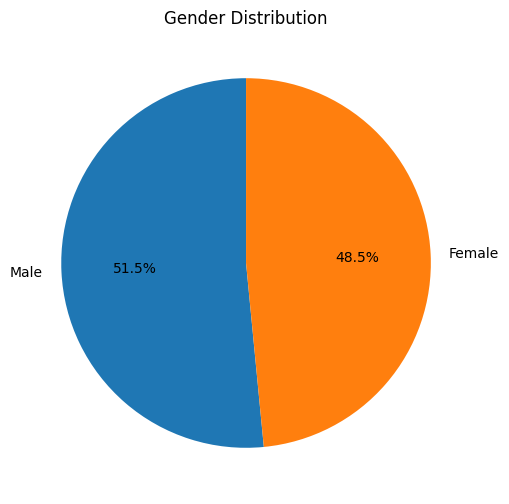

In [32]:
sex_counts = EMG_df['sex'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(sex_counts,
        labels=sex_counts.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Gender Distribution")
plt.show()

In [33]:
EMG_df['dominant Hand'] = EMG_df['dominant Hand'].replace({
    'left': 'Left',
    'right': 'Right'
})

In [34]:
EMG_df = EMG_df.drop(columns=['patient_id'])

##Encoding

In [35]:
EMG_encoded = EMG_df.copy()

###1) Binary Encoding

In [36]:
# Encode binary categorical variables using Mapping


EMG_encoded['sex'] = EMG_encoded['sex'].map({
    'Male': 1,
    'Female': 0
})

EMG_encoded['side'] = EMG_encoded['side'].map({
    'Right': 1,
    'Left': 0
})

EMG_encoded['dominant Hand'] = EMG_encoded['dominant Hand'].map({
    'Right': 1,
    'Left': 0
})

###**2) One-Hot Encoding**

In [37]:
# For Liner Models                -> Nerve_Ulnar, Nerve_Radial

'''
# Apply One-Hot Encoding for the 'Nerve' column
# This converts each nerve type into separate binary columns

EMG_encoded = pd.get_dummies(EMG_encoded, columns=['Nerve'], drop_first=True)

# Type conversation
EMG_encoded[['Nerve_Radial','Nerve_Ulnar']] = EMG_encoded[['Nerve_Radial','Nerve_Ulnar']].astype(int)
'''

"\n# Apply One-Hot Encoding for the 'Nerve' column\n# This converts each nerve type into separate binary columns\n\nEMG_encoded = pd.get_dummies(EMG_encoded, columns=['Nerve'], drop_first=True)\n\n# Type conversation\nEMG_encoded[['Nerve_Radial','Nerve_Ulnar']] = EMG_encoded[['Nerve_Radial','Nerve_Ulnar']].astype(int)\n"

In [38]:
# For Liner Models                -> Nerve_Median, Nerve_Ulnar, Nerve_Radial


# Create one-hot encoded columns for the 'Nerve' feature -> will generate 3 columns: Nerve_Median, Nerve_Ulnar, Nerve_Radial
nerve_dummies = pd.get_dummies(EMG_encoded['Nerve'], prefix='Nerve')

# Convert the dummy variables from boolean/uint to integer (0 and 1)
nerve_dummies = nerve_dummies.astype(int)

# Concatenate the new one-hot encoded columns with the main dataframe
EMG_encoded = pd.concat([EMG_encoded, nerve_dummies], axis=1)

# Drop the original 'Nerve' column since it is now encoded
EMG_encoded.drop('Nerve', axis=1, inplace=True)

###**3) Ordinal Encoding**

In [39]:
# Encode the target variable (Diagnosis Severity)

EMG_encoded['Diagnosis Severity'] = EMG_encoded['Diagnosis Severity'].map({
    'Normal': 0,
    'Mild': 1,
    'Moderate': 2,
    'Severe': 3
})

##Arrange Cols

In [40]:
# Define the target column (the variable we want the model to predict)
target = 'Diagnosis Severity'


# Create a list of columns where the target column is placed at the end
# First take all columns except the target, then add the target column last
cols = [col for col in EMG_encoded.columns if col != target] + [target]


# Reorder the dataframe columns based on the new column list to ensures the target variable appears as the last column
EMG_encoded = EMG_encoded[cols]


# Display the first 5 rows of the dataframe to verify the new column order
EMG_encoded.head()

,age,sex,side,dominant Hand,MUAP Amplitude uV,MUAP Ration ms,MUAP Polyphasia Percent,Firing Rate hz,Nerve_Median,Nerve_Radial,Nerve_Ulnar,Diagnosis Severity
0,69,0,0,1,751.0,10.0,4.7,12.8,1,0,0,0
1,26,0,1,1,2798.0,13.4,23.9,12.2,0,0,1,2
2,47,0,1,1,946.0,9.8,5.8,8.9,0,0,1,0
3,25,1,0,1,1217.0,8.7,14.2,20.1,1,0,0,0
4,41,0,1,1,2763.0,16.3,22.9,17.9,1,0,0,2


##**Train/Test Split**

In [41]:
from sklearn.model_selection import train_test_split

# Separate
X = EMG_encoded.drop(columns=['Diagnosis Severity'])

# target variable
y = EMG_encoded['Diagnosis Severity']


# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,                 # Feature matrix (input variables)
    y,                 # Target variable
    test_size=0.2,     # 20% of the data will be used for testing
    random_state=42,   # Ensures reproducibility (same split every run)
    stratify=y         # Keeps the same class distribution in train and test sets
)

##**Feature Selection**

###1) Statistical Feature Selection

**1) Kruskal-Wallis Test For The Numeric Feature**

In [42]:
from scipy.stats import kruskal
import pandas as pd

# List of numerical features to test their relationship with the target variable
numeric_features = [
    'age',
    'MUAP Amplitude uV',
    'MUAP Ration ms',
    'MUAP Polyphasia Percent',
    'Firing Rate hz'
]

# List to store test results
results = []

# Loop through each numeric feature
for feature in numeric_features:

    # Create a list that will hold the values of the feature for each class of the target
    groups = []

    # For each class in the target variable (Diagnosis Severity)
    for cls in y_train.unique():
        # Select values of the feature corresponding to that class
        groups.append(X_train[y_train == cls][feature])

    # Apply the Kruskal-Wallis test to compare distributions across groups
    stat, p = kruskal(*groups)

    # Store the feature name and its p-value
    results.append({
        'Feature': feature,
        'p-value': p
    })

# Convert results into a DataFrame for easier analysis
results_df = pd.DataFrame(results)

# Mark features as significant if p-value ≤ 0.05
results_df["Significant (p≤0.05)"] = results_df["p-value"].apply(
    lambda x: "Yes" if x <= 0.05 else "No"
)

# Sort features by p-value (most significant first)
results_df = results_df.sort_values("p-value")

# Display the results
results_df

,Feature,p-value,Significant (p≤0.05)
3,MUAP Polyphasia Percent,2.223773e-88,Yes
2,MUAP Ration ms,4.456013e-50,Yes
1,MUAP Amplitude uV,1.568909e-26,Yes
4,Firing Rate hz,2.111645e-01,No
0,age,2.169704e-01,No


**2) Chi-Square Test For The Categorical Features**

In [43]:
from scipy.stats import chi2_contingency
import pandas as pd

# List of categorical features to test their relationship with the target
categorical_features = [
    'sex',
    'side',
    'dominant Hand',
    'Nerve_Median',
    'Nerve_Ulnar',
    'Nerve_Radial'
]

# List to store chi-square test results
chi_results = []

# Loop through each categorical feature
for feature in categorical_features:

    # Create a contingency table between the feature and the target variable
    table = pd.crosstab(X_train[feature], y_train)

    # Perform the Chi-Square test of independence
    chi2, p, dof, expected = chi2_contingency(table)

    # Store the feature name and its p-value
    chi_results.append({
        "Feature": feature,
        "p-value": p
    })

# Convert results into a DataFrame
chi_df = pd.DataFrame(chi_results)

# Sort features by p-value (most significant first)
chi_df = chi_df.sort_values("p-value")

# Mark features as significant if p-value ≤ 0.05
chi_df["Significant (p≤0.05)"] = chi_df["p-value"].apply(
    lambda x: "Yes" if x <= 0.05 else "No"
)

# Display the results
chi_df

,Feature,p-value,Significant (p≤0.05)
1,side,0.020407,Yes
5,Nerve_Radial,0.089099,No
4,Nerve_Ulnar,0.340381,No
2,dominant Hand,0.412273,No
0,sex,0.511668,No
3,Nerve_Median,0.742346,No


###2) Fisher Score

In [44]:
# ANOVA F-test function
from sklearn.feature_selection import f_classif
import pandas as pd


# Apply the ANOVA F-test between each feature in X_train and the target variable y_train
# This test evaluates whether the mean values of a feature differ significantly across target classes
f_scores, p_values = f_classif(
    X_train,
    y_train
    )


# create Df to organize the results
fisher_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Fisher Score': f_scores,
    'p-value': p_values
})


# Sort descending order : Higher Fisher Score indicates stronger relationship with the target variable
fisher_df = fisher_df.sort_values(by='Fisher Score', ascending=False)



fisher_df

,Feature,Fisher Score,p-value
6,MUAP Polyphasia Percent,391.294215,4.420249e-151
5,MUAP Ration ms,123.431891,1.382409e-64
4,MUAP Amplitude uV,63.614080,1.609797e-36
2,side,3.290757,2.022990e-02
9,Nerve_Radial,2.178998,8.918328e-02
0,age,1.461124,2.238847e-01
7,Firing Rate hz,1.325265,2.649770e-01
10,Nerve_Ulnar,1.116555,3.415308e-01
3,dominant Hand,0.954832,4.135851e-01
1,sex,0.766359,5.130919e-01


### 3) Selected Features

selected_features = [
'MUAP Polyphasia Percent',
'MUAP Ration ms',
'MUAP Amplitude uV',
]

X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

##**Feature Scalling**

In [45]:
'''
from sklearn.preprocessing import StandardScaler

# Create a scaler object
scaler = StandardScaler()


# Fit the scaler on the training data & transform it
X_train_scaled = scaler.fit_transform(X_train)


# we only transform the test data (do not fit again) to prevents data leakage
X_test_scaled = scaler.transform(X_test)
'''

'\nfrom sklearn.preprocessing import StandardScaler\n\n# Create a scaler object\nscaler = StandardScaler()\n\n\n# Fit the scaler on the training data & transform it\nX_train_scaled = scaler.fit_transform(X_train)\n\n\n# we only transform the test data (do not fit again) to prevents data leakage\nX_test_scaled = scaler.transform(X_test)\n'

In [46]:
'''
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(X_train_selected)


X_test_scaled = scaler.transform(X_test_selected)
'''

'\nfrom sklearn.preprocessing import StandardScaler\n\nscaler = StandardScaler()\n\n\nX_train_scaled = scaler.fit_transform(X_train_selected)\n\n\nX_test_scaled = scaler.transform(X_test_selected)\n'

In [47]:
'''\
# convert into DataFrame

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

# Debug
X_train_scaled.head()
'''

'# convert into DataFrame\n\nX_train_scaled = pd.DataFrame(\n    X_train_scaled,\n    columns=X_train.columns,\n    index=X_train.index\n)\n\nX_test_scaled = pd.DataFrame(\n    X_test_scaled,\n    columns=X_test.columns,\n    index=X_test.index\n)\n\n# Debug\nX_train_scaled.head()\n'

In [48]:
'''
''print((X_train_scaled.index == y_train.index).all())
'''

"\n''print((X_train_scaled.index == y_train.index).all())\n"

# ________________________________________________________________________________________________________

# Model Implementation

## Cross Vaildation Function

In [49]:
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, average_precision_score,
    classification_report, confusion_matrix
)
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


def run_svm_stratified_cv(X, y, experiment_name, model_params=None):

    # Copy features to avoid changing the original data
    X = X.copy()
    X.columns = X.columns.str.replace(' ', '_')

    # Define target mapping
    target_mapping = {
        'Normal': 0,
        'Mild': 1,
        'Moderate': 2,
        'Severe': 3
    }

    # Keep class order fixed
    sorted_classes = sorted(target_mapping.items(), key=lambda x: x[1])
    class_names = [name for name, _ in sorted_classes]
    class_labels = [label for _, label in sorted_classes]

    # Get Severe class info for AP
    severe_label = target_mapping['Severe']
    severe_index = class_labels.index(severe_label)

    # Stratified 5-fold CV
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Store outputs
    metrics_list = []
    fold_reports = []
    confusion_matrices = []

    # Store all predictions across folds
    all_y_true = []
    all_y_pred = []
    all_y_proba = []

    # Default baseline parameters for SVM
    default_params = {
        'C': 1.0,
        'kernel': 'rbf',
        'gamma': 'scale',
        'class_weight': 'balanced',
        'probability': True,
        'random_state': 42
    }

    # Update with tuned parameters if provided
    if model_params is not None:
        default_params.update(model_params)

    print("\n" + "=" * 100)
    print(f"Experiment: {experiment_name}")
    print("=" * 100)

    # Loop through folds
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):

        # Split current fold
        X_train_fold = X.iloc[train_idx].copy()
        X_val_fold = X.iloc[val_idx].copy()
        y_train_fold = y.iloc[train_idx]
        y_val_fold = y.iloc[val_idx]

        # Scale inside each fold to avoid data leakage
        scaler = StandardScaler()
        X_train_fold_scaled = scaler.fit_transform(X_train_fold)
        X_val_fold_scaled = scaler.transform(X_val_fold)

        # Train model
        model = SVC(**default_params)
        model.fit(X_train_fold_scaled, y_train_fold)

        # Predict labels and probabilities
        y_pred = model.predict(X_val_fold_scaled)
        y_proba = model.predict_proba(X_val_fold_scaled)

        # Save all predictions across folds
        all_y_true.extend(y_val_fold.tolist())
        all_y_pred.extend(y_pred.tolist())
        all_y_proba.append(y_proba)

        # Calculate fold metrics
        acc = accuracy_score(y_val_fold, y_pred)
        precision_macro = precision_score(y_val_fold, y_pred, average='macro', zero_division=0)
        recall_macro = recall_score(y_val_fold, y_pred, average='macro', zero_division=0)
        f1_macro = f1_score(y_val_fold, y_pred, average='macro', zero_division=0)
        mcc = matthews_corrcoef(y_val_fold, y_pred)

        # Calculate AP for Severe class
        y_val_severe = (y_val_fold == severe_label).astype(int)
        y_proba_severe = y_proba[:, severe_index]
        ap_severe = average_precision_score(y_val_severe, y_proba_severe)

        # Save fold metrics
        metrics_list.append({
            'Fold': fold,
            'Accuracy': round(acc, 4),
            'Precision_macro': round(precision_macro, 4),
            'Recall_macro': round(recall_macro, 4),
            'F1_macro': round(f1_macro, 4),
            'MCC': round(mcc, 4),
            'AP_Severe': round(ap_severe, 4)
        })

        # Build classification report for current fold
        report_dict = classification_report(
            y_val_fold,
            y_pred,
            labels=class_labels,
            target_names=class_names,
            output_dict=True,
            zero_division=0
        )

        report_df = pd.DataFrame(report_dict).transpose()
        report_df.insert(0, 'Fold', fold)
        fold_reports.append(report_df)

        # Build confusion matrix for current fold
        cm = confusion_matrix(y_val_fold, y_pred, labels=class_labels)
        confusion_matrices.append(cm)

    # Convert fold metrics to DataFrame
    summary_df = pd.DataFrame(metrics_list)

    print("\nFold-wise Metrics")
    print("-" * 100)
    display(summary_df)

    print("\nClassification Report for Each Fold")
    print("-" * 100)
    for i, report_df in enumerate(fold_reports, start=1):
        print(f"\nFold {i}")
        display(report_df.loc[class_names + ['accuracy', 'macro avg', 'weighted avg']])

    print("\n" + "=" * 100)
    print("Confusion Matrices for Each Fold")
    print("=" * 100)

    # Plot confusion matrix for each fold
    for i, cm in enumerate(confusion_matrices, start=1):
        plt.figure(figsize=(6, 5))
        sns.heatmap(
            cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names
        )
        plt.title(f"{experiment_name} - Fold {i}")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.tight_layout()
        plt.show()

    # Convert all predictions to arrays
    all_y_true = np.array(all_y_true)
    all_y_pred = np.array(all_y_pred)
    all_y_proba = np.vstack(all_y_proba)

    # Aggregated metrics across all folds
    agg_accuracy = accuracy_score(all_y_true, all_y_pred)
    agg_precision = precision_score(all_y_true, all_y_pred, average='macro', zero_division=0)
    agg_recall = recall_score(all_y_true, all_y_pred, average='macro', zero_division=0)
    agg_f1 = f1_score(all_y_true, all_y_pred, average='macro', zero_division=0)
    agg_mcc = matthews_corrcoef(all_y_true, all_y_pred)

    # Aggregated AP for Severe class
    y_true_severe = (all_y_true == severe_label).astype(int)
    y_proba_severe_all = all_y_proba[:, severe_index]
    agg_ap_severe = average_precision_score(y_true_severe, y_proba_severe_all)

    aggregated_metrics_df = pd.DataFrame([{
        'Accuracy': round(agg_accuracy, 4),
        'Precision_macro': round(agg_precision, 4),
        'Recall_macro': round(agg_recall, 4),
        'F1_macro': round(agg_f1, 4),
        'MCC': round(agg_mcc, 4),
        'AP_Severe': round(agg_ap_severe, 4)
    }])

    print("\nAggregated Metrics Across All Folds")
    print("-" * 100)
    display(aggregated_metrics_df)

    # Aggregated classification report across all folds
    aggregated_report_dict = classification_report(
        all_y_true,
        all_y_pred,
        labels=class_labels,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    aggregated_report_df = pd.DataFrame(aggregated_report_dict).transpose().round(4)

    print("\nAggregated Classification Report Across All Folds")
    print("-" * 100)
    display(aggregated_report_df.loc[class_names + ['accuracy', 'macro avg', 'weighted avg']])

    # Aggregated confusion matrix
    total_cm = np.sum(confusion_matrices, axis=0)

    print("\n" + "=" * 100)
    print("Aggregated Confusion Matrix")
    print("=" * 100)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        total_cm,
        annot=True,
        fmt='d',
        cmap='Greens',
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title(f"{experiment_name} - Aggregated Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    # Combine all fold reports
    all_reports_df = pd.concat(fold_reports, axis=0)

    return summary_df, all_reports_df, aggregated_metrics_df, aggregated_report_df, total_cm

##SVM Baseline (ALL FEATUERS)


Experiment: SVM Baseline - All Features

Fold-wise Metrics
----------------------------------------------------------------------------------------------------


,Fold,Accuracy,Precision_macro,Recall_macro,F1_macro,MCC,AP_Severe
0,1,0.6781,0.6518,0.6842,0.6615,0.5500,0.8998
1,2,0.6507,0.6676,0.6721,0.6693,0.5066,0.9270
2,3,0.6644,0.6473,0.6502,0.6485,0.5281,0.7821
3,4,0.6712,0.6722,0.6811,0.6750,0.5389,0.7250
4,5,0.6552,0.6515,0.6630,0.6542,0.5185,0.7877



Classification Report for Each Fold
----------------------------------------------------------------------------------------------------

Fold 1


,Fold,precision,recall,f1-score,support
Normal,1,0.766667,0.821429,0.793103,56.000000
Mild,1,0.648649,0.571429,0.607595,42.000000
Moderate,1,0.555556,0.468750,0.508475,32.000000
Severe,1,0.636364,0.875000,0.736842,16.000000
accuracy,1,0.678082,0.678082,0.678082,0.678082
macro avg,1,0.651809,0.684152,0.661504,146.000000
weighted avg,1,0.672166,0.678082,0.671188,146.000000



Fold 2


...


Fold 4


,Fold,precision,recall,f1-score,support
Normal,4,0.700000,0.750000,0.724138,56.000000
Mild,4,0.600000,0.500000,0.545455,42.000000
Moderate,4,0.666667,0.709677,0.687500,31.000000
Severe,4,0.722222,0.764706,0.742857,17.000000
accuracy,4,0.671233,0.671233,0.671233,0.671233
macro avg,4,0.672222,0.681096,0.674987,146.000000
weighted avg,4,0.666743,0.671233,0.667136,146.000000



Fold 5


,Fold,precision,recall,f1-score,support
Normal,5,0.745098,0.678571,0.710280,56.000000
Mild,5,0.562500,0.642857,0.600000,42.000000
Moderate,5,0.666667,0.580645,0.620690,31.000000
Severe,5,0.631579,0.750000,0.685714,16.000000
accuracy,5,0.655172,0.655172,0.655172,0.655172
macro avg,5,0.651461,0.663018,0.654171,145.000000
weighted avg,5,0.662913,0.655172,0.656472,145.000000



Confusion Matrices for Each Fold


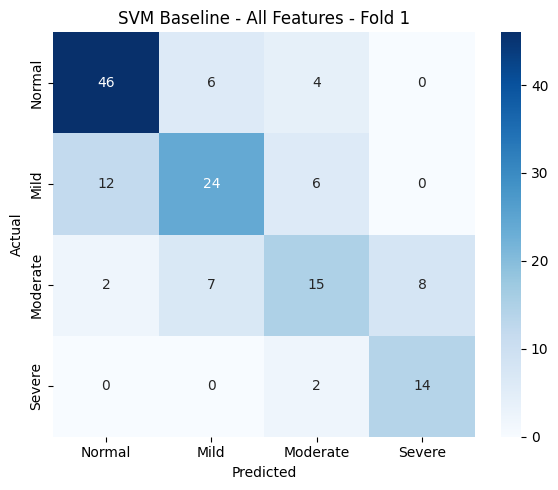

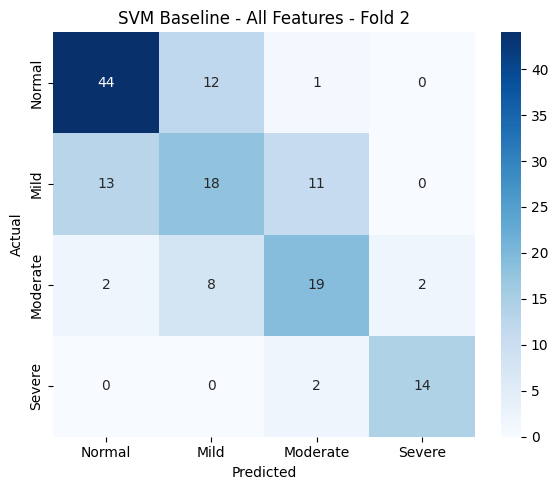

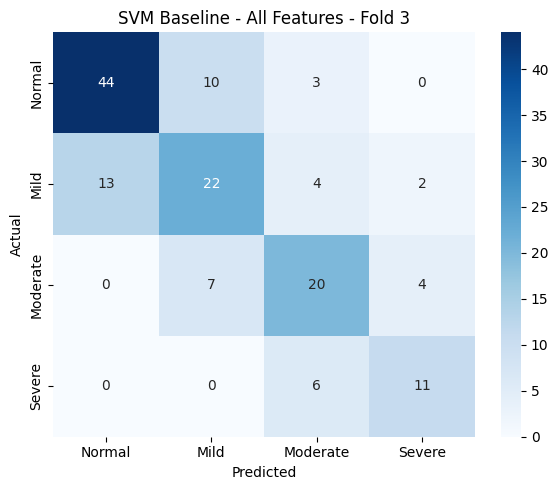

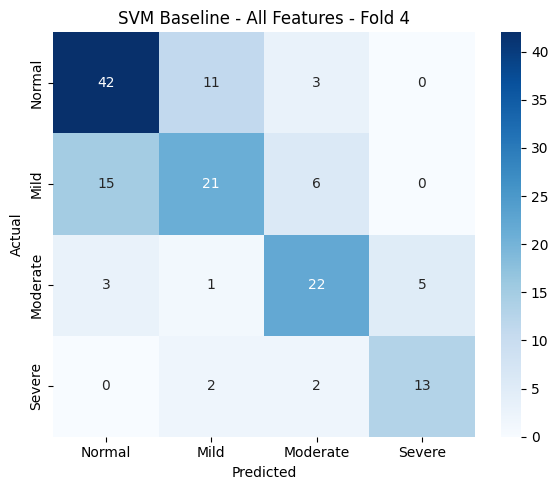

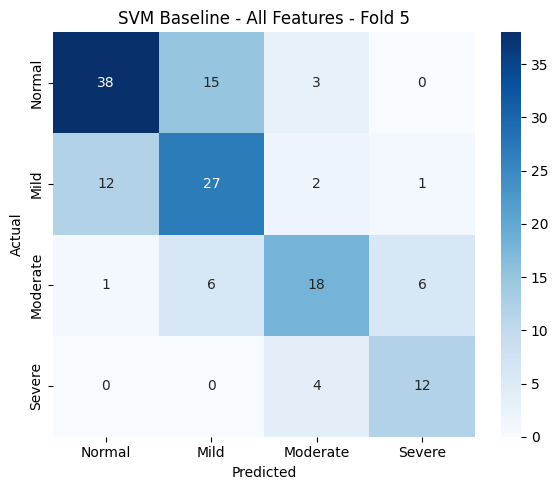


Aggregated Metrics Across All Folds
----------------------------------------------------------------------------------------------------


,Accuracy,Precision_macro,Recall_macro,F1_macro,MCC,AP_Severe
0,0.6639,0.6561,0.6695,0.662,0.5276,0.7903



Aggregated Classification Report Across All Folds
----------------------------------------------------------------------------------------------------


,precision,recall,f1-score,support
Normal,0.7456,0.7589,0.7522,282.0000
Mild,0.5685,0.5359,0.5517,209.0000
Moderate,0.6144,0.6026,0.6084,156.0000
Severe,0.6957,0.7805,0.7356,82.0000
accuracy,0.6639,0.6639,0.6639,0.6639
macro avg,0.6561,0.6695,0.6620,729.0000
weighted avg,0.6612,0.6639,0.6621,729.0000



Aggregated Confusion Matrix


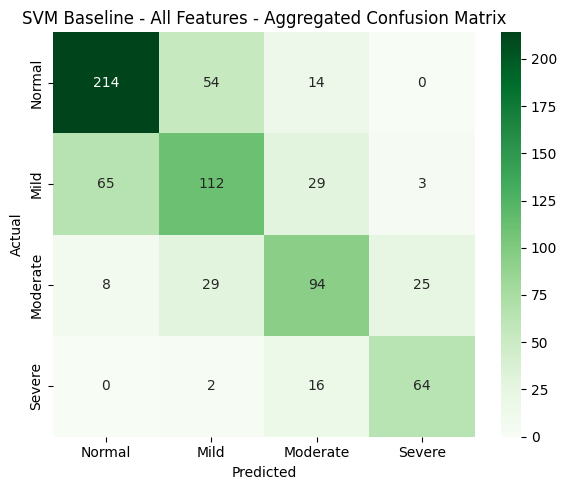

In [50]:
all_features_results, all_feature_reports, all_feature_agg_metrics, all_feature_agg_report, all_feature_cm = run_svm_stratified_cv(
    X=X_train,
    y=y_train,
    experiment_name='SVM Baseline - All Features'
)

##SVM - Selected Features


Experiment: SVM Baseline - Selected Features

Fold-wise Metrics
----------------------------------------------------------------------------------------------------


,Fold,Accuracy,Precision_macro,Recall_macro,F1_macro,MCC,AP_Severe
0,1,0.6644,0.6707,0.6983,0.6813,0.5316,0.8821
1,2,0.6712,0.6569,0.6821,0.6665,0.5397,0.8979
2,3,0.6986,0.6879,0.7068,0.6955,0.5794,0.8413
3,4,0.6644,0.6704,0.6913,0.6785,0.5362,0.7027
4,5,0.6828,0.6779,0.7114,0.6904,0.5570,0.7987



Classification Report for Each Fold
----------------------------------------------------------------------------------------------------

Fold 1


,Fold,precision,recall,f1-score,support
Normal,1,0.754717,0.714286,0.733945,56.000000
Mild,1,0.522727,0.547619,0.534884,42.000000
Moderate,1,0.655172,0.593750,0.622951,32.000000
Severe,1,0.750000,0.937500,0.833333,16.000000
accuracy,1,0.664384,0.664384,0.664384,0.664384
macro avg,1,0.670654,0.698289,0.681278,146.000000
weighted avg,1,0.665645,0.664384,0.663245,146.000000



Fold 2


...


Fold 4


,Fold,precision,recall,f1-score,support
Normal,4,0.770833,0.660714,0.711538,56.000000
Mild,4,0.545455,0.571429,0.558140,42.000000
Moderate,4,0.628571,0.709677,0.666667,31.000000
Severe,4,0.736842,0.823529,0.777778,17.000000
accuracy,4,0.664384,0.664384,0.664384,0.664384
macro avg,4,0.670425,0.691337,0.678531,146.000000
weighted avg,4,0.671834,0.664384,0.665595,146.000000



Fold 5


,Fold,precision,recall,f1-score,support
Normal,5,0.759259,0.732143,0.745455,56.000000
Mild,5,0.595238,0.595238,0.595238,42.000000
Moderate,5,0.642857,0.580645,0.610169,31.000000
Severe,5,0.714286,0.937500,0.810811,16.000000
accuracy,5,0.682759,0.682759,0.682759,0.682759
macro avg,5,0.677910,0.711382,0.690418,145.000000
weighted avg,5,0.681901,0.682759,0.680232,145.000000



Confusion Matrices for Each Fold


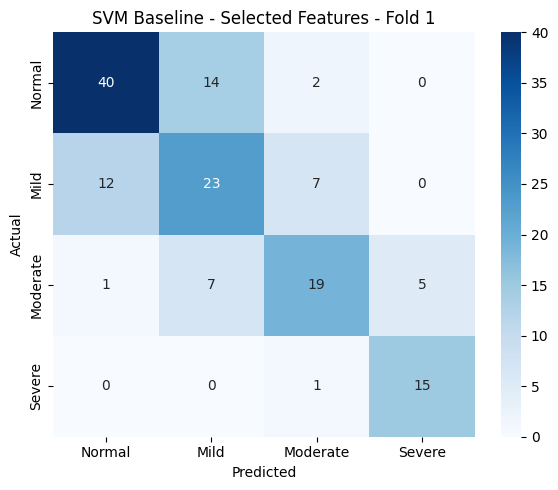

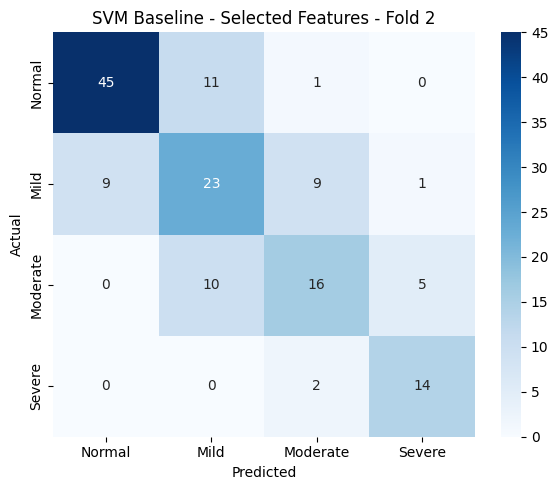

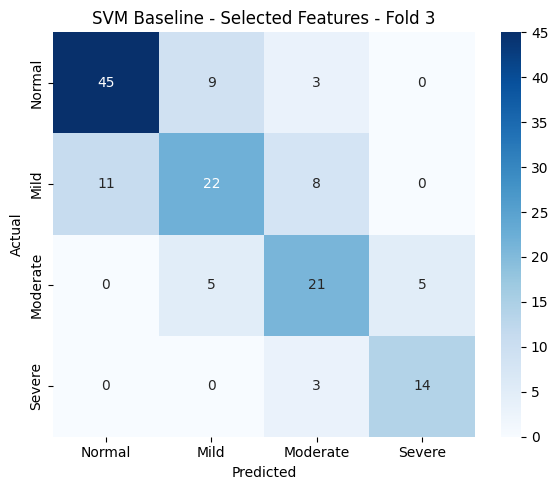

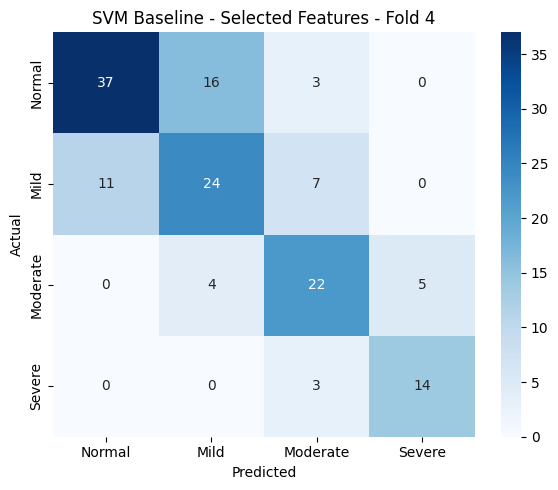

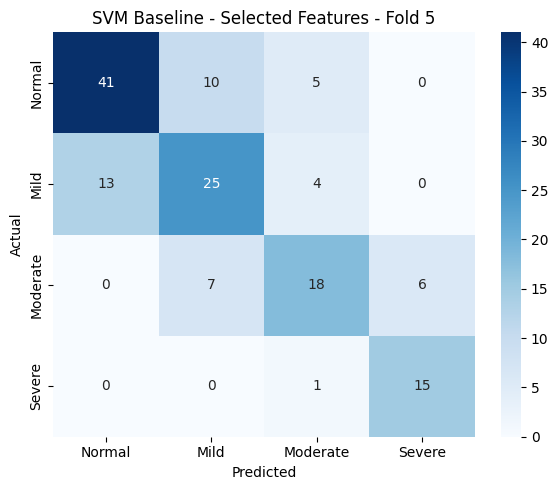


Aggregated Metrics Across All Folds
----------------------------------------------------------------------------------------------------


,Accuracy,Precision_macro,Recall_macro,F1_macro,MCC,AP_Severe
0,0.6763,0.6722,0.6977,0.683,0.5483,0.7845



Aggregated Classification Report Across All Folds
----------------------------------------------------------------------------------------------------


,precision,recall,f1-score,support
Normal,0.7849,0.7376,0.7605,282.0000
Mild,0.5571,0.5598,0.5585,209.0000
Moderate,0.6194,0.6154,0.6174,156.0000
Severe,0.7273,0.8780,0.7956,82.0000
accuracy,0.6763,0.6763,0.6763,0.6763
macro avg,0.6722,0.6977,0.6830,729.0000
weighted avg,0.6777,0.6763,0.6759,729.0000



Aggregated Confusion Matrix


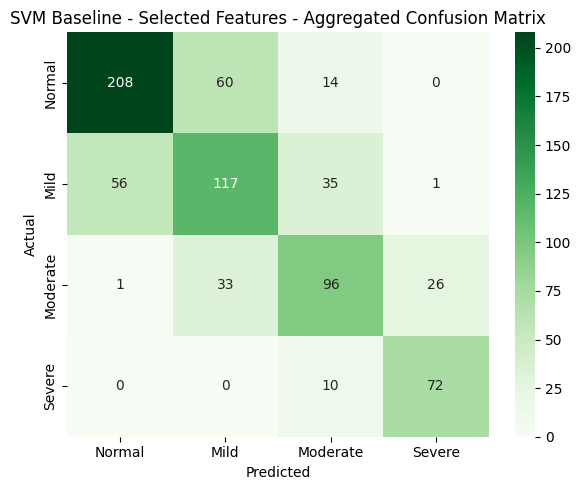

In [51]:
selected_features = [
    'MUAP Polyphasia Percent',
    'MUAP Ration ms',
    'MUAP Amplitude uV'
]

X_train_selected = X_train[selected_features].copy()

selected_features_results, selected_feature_reports, selected_feature_agg_metrics, selected_feature_agg_report, selected_feature_cm = run_svm_stratified_cv(
    X=X_train_selected,
    y=y_train,
    experiment_name='SVM Baseline - Selected Features'
)

# ________________________________________________________________________________________________________

In [52]:
baseline_comparison = pd.DataFrame({
    'All Features': all_features_results.drop(columns='Fold').mean(),
    'Selected Features': selected_features_results.drop(columns='Fold').mean()
})

print("SVM Baseline Comparison")
display(baseline_comparison)

SVM Baseline Comparison


,All Features,Selected Features
Accuracy,0.66392,0.67628
Precision_macro,0.65808,0.67276
Recall_macro,0.67012,0.69798
F1_macro,0.66170,0.68244
MCC,0.52842,0.54878
AP_Severe,0.82432,0.82454


In [53]:
print("All Features - Aggregated Classification Report")
display(all_feature_agg_report.loc[['Normal', 'Mild', 'Moderate', 'Severe', 'accuracy', 'macro avg', 'weighted avg']])

print('-'*100)

print("\nSelected Features - Aggregated Classification Report")
display(selected_feature_agg_report.loc[['Normal', 'Mild', 'Moderate', 'Severe', 'accuracy', 'macro avg', 'weighted avg']])

All Features - Aggregated Classification Report


,precision,recall,f1-score,support
Normal,0.7456,0.7589,0.7522,282.0000
Mild,0.5685,0.5359,0.5517,209.0000
Moderate,0.6144,0.6026,0.6084,156.0000
Severe,0.6957,0.7805,0.7356,82.0000
accuracy,0.6639,0.6639,0.6639,0.6639
macro avg,0.6561,0.6695,0.6620,729.0000
weighted avg,0.6612,0.6639,0.6621,729.0000


----------------------------------------------------------------------------------------------------

Selected Features - Aggregated Classification Report


,precision,recall,f1-score,support
Normal,0.7849,0.7376,0.7605,282.0000
Mild,0.5571,0.5598,0.5585,209.0000
Moderate,0.6194,0.6154,0.6174,156.0000
Severe,0.7273,0.8780,0.7956,82.0000
accuracy,0.6763,0.6763,0.6763,0.6763
macro avg,0.6722,0.6977,0.6830,729.0000
weighted avg,0.6777,0.6763,0.6759,729.0000


# Hyperprametrs Tunning

In [54]:
from itertools import product

# Define SVM hyperparameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 1, 0.1, 0.01, 0.001]
}

# Create all combinations manually
all_param_combinations = list(product(
    param_grid['C'],
    param_grid['kernel'],
    param_grid['gamma']
))

print(f"Total combinations: {len(all_param_combinations)}")

Total combinations: 50


In [55]:
# Store summary results for all combinations
all_combo_results = []

# Loop through all combinations
for combo_id, (C, kernel, gamma) in enumerate(all_param_combinations, start=1):

    # Current parameter set
    model_params = {
        'C': C,
        'kernel': kernel,
        'gamma': gamma,
        'class_weight': 'balanced',
        'probability': True,
        'random_state': 42
    }

    # Use selected features here
    X_used = X_train_selected.copy()
    X_used.columns = X_used.columns.str.replace(' ', '_')
    y_used = y_train.copy()

    # Fixed class info
    target_mapping = {
        'Normal': 0,
        'Mild': 1,
        'Moderate': 2,
        'Severe': 3
    }

    class_labels = [0, 1, 2, 3]
    severe_label = target_mapping['Severe']
    severe_index = class_labels.index(severe_label)

    # 5-fold CV
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Store fold metrics for this combination
    combo_fold_results = []

    # Store all predictions across folds for aggregated metrics
    all_y_true = []
    all_y_pred = []
    all_y_proba = []

    # Loop through folds
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_used, y_used), start=1):

        # Split current fold
        X_train_fold = X_used.iloc[train_idx].copy()
        X_val_fold = X_used.iloc[val_idx].copy()
        y_train_fold = y_used.iloc[train_idx]
        y_val_fold = y_used.iloc[val_idx]

        # Scale inside each fold
        scaler = StandardScaler()
        X_train_fold_scaled = scaler.fit_transform(X_train_fold)
        X_val_fold_scaled = scaler.transform(X_val_fold)

        # Build model
        model = SVC(**model_params)

        # Train model
        model.fit(X_train_fold_scaled, y_train_fold)

        # Predict labels and probabilities
        y_pred = model.predict(X_val_fold_scaled)
        y_proba = model.predict_proba(X_val_fold_scaled)

        # Save all predictions for aggregated metrics
        all_y_true.extend(y_val_fold.tolist())
        all_y_pred.extend(y_pred.tolist())
        all_y_proba.append(y_proba)

        # Calculate fold metrics
        acc = accuracy_score(y_val_fold, y_pred)
        precision_macro = precision_score(y_val_fold, y_pred, average='macro', zero_division=0)
        recall_macro = recall_score(y_val_fold, y_pred, average='macro', zero_division=0)
        f1_macro = f1_score(y_val_fold, y_pred, average='macro', zero_division=0)
        mcc = matthews_corrcoef(y_val_fold, y_pred)

        # Calculate AP for Severe class
        y_val_severe = (y_val_fold == severe_label).astype(int)
        y_proba_severe = y_proba[:, severe_index]
        ap_severe = average_precision_score(y_val_severe, y_proba_severe)

        # Save fold metrics
        combo_fold_results.append({
            'Fold': fold,
            'Accuracy': round(acc, 4),
            'Precision_macro': round(precision_macro, 4),
            'Recall_macro': round(recall_macro, 4),
            'F1_macro': round(f1_macro, 4),
            'MCC': round(mcc, 4),
            'AP_Severe': round(ap_severe, 4)
        })

    # Convert fold metrics to DataFrame
    combo_fold_df = pd.DataFrame(combo_fold_results)

    # Convert aggregated predictions to arrays
    all_y_true = np.array(all_y_true)
    all_y_pred = np.array(all_y_pred)
    all_y_proba = np.vstack(all_y_proba)

    # Calculate aggregated metrics across all folds
    agg_accuracy = accuracy_score(all_y_true, all_y_pred)
    agg_precision = precision_score(all_y_true, all_y_pred, average='macro', zero_division=0)
    agg_recall = recall_score(all_y_true, all_y_pred, average='macro', zero_division=0)
    agg_f1 = f1_score(all_y_true, all_y_pred, average='macro', zero_division=0)
    agg_mcc = matthews_corrcoef(all_y_true, all_y_pred)

    # Calculate aggregated AP for Severe class
    y_true_severe = (all_y_true == severe_label).astype(int)
    y_proba_severe_all = all_y_proba[:, severe_index]
    agg_ap_severe = average_precision_score(y_true_severe, y_proba_severe_all)

    print(f"\n{'=' * 120}")
    print(f"Combination {combo_id}/{len(all_param_combinations)}")
    print(
        f"C={C}, kernel={kernel}, gamma={gamma}"
    )

    print("\nFold-wise Results:")
    display(combo_fold_df)

    # Save mean + aggregated metrics
    combo_summary = {
        'Combo_ID': combo_id,
        'C': C,
        'kernel': kernel,
        'gamma': gamma,

        'Accuracy_Mean': round(combo_fold_df['Accuracy'].mean(), 4),
        'Precision_Mean': round(combo_fold_df['Precision_macro'].mean(), 4),
        'Recall_Mean': round(combo_fold_df['Recall_macro'].mean(), 4),
        'F1_Mean': round(combo_fold_df['F1_macro'].mean(), 4),
        'MCC_Mean': round(combo_fold_df['MCC'].mean(), 4),
        'AP_Severe_Mean': round(combo_fold_df['AP_Severe'].mean(), 4),

        'Accuracy_Agg': round(agg_accuracy, 4),
        'Precision_Agg': round(agg_precision, 4),
        'Recall_Agg': round(agg_recall, 4),
        'F1_Agg': round(agg_f1, 4),
        'MCC_Agg': round(agg_mcc, 4),
        'AP_Severe_Agg': round(agg_ap_severe, 4)
    }

    all_combo_results.append(combo_summary)

    # Print summary for this combination
    print(
        f"[{combo_id:03}] "
        f"Accuracy_Mean={combo_summary['Accuracy_Mean']:.4f} | "
        f"Precision_Mean={combo_summary['Precision_Mean']:.4f} | "
        f"Recall_Mean={combo_summary['Recall_Mean']:.4f} | "
        f"F1_Mean={combo_summary['F1_Mean']:.4f} | "
        f"MCC_Mean={combo_summary['MCC_Mean']:.4f} | "
        f"AP_Severe_Mean={combo_summary['AP_Severe_Mean']:.4f}"
    )

    print(
        f"Aggregated -> "
        f"Accuracy={combo_summary['Accuracy_Agg']:.4f} | "
        f"Precision={combo_summary['Precision_Agg']:.4f} | "
        f"Recall={combo_summary['Recall_Agg']:.4f} | "
        f"F1={combo_summary['F1_Agg']:.4f} | "
        f"MCC={combo_summary['MCC_Agg']:.4f} | "
        f"AP_Severe={combo_summary['AP_Severe_Agg']:.4f}"
    )

# Convert all results to DataFrame
all_combo_results_df = pd.DataFrame(all_combo_results)


Combination 1/50
C=0.01, kernel=linear, gamma=scale

Fold-wise Results:


,Fold,Accuracy,Precision_macro,Recall_macro,F1_macro,MCC,AP_Severe
0,1,0.6575,0.6641,0.6678,0.6561,0.5174,0.7970
1,2,0.6507,0.6268,0.6516,0.6339,0.5061,0.8620
2,3,0.6986,0.6710,0.6721,0.6700,0.5747,0.7505
3,4,0.6644,0.6561,0.6529,0.6530,0.5267,0.7138
4,5,0.6690,0.6670,0.6769,0.6640,0.5341,0.8931


[001] Accuracy_Mean=0.6680 | Precision_Mean=0.6570 | Recall_Mean=0.6643 | F1_Mean=0.6554 | MCC_Mean=0.5318 | AP_Severe_Mean=0.8033
Aggregated -> Accuracy=0.6680 | Precision=0.6567 | Recall=0.6635 | F1=0.6564 | MCC=0.5313 | AP_Severe=0.7957

Combination 2/50
C=0.01, kernel=linear, gamma=1

Fold-wise Results:


,Fold,Accuracy,Precision_macro,Recall_macro,F1_macro,MCC,AP_Severe
0,1,0.6575,0.6641,0.6678,0.6561,0.5174,0.7970
1,2,0.6507,0.6268,0.6516,0.6339,0.5061,0.8620
2,3,0.6986,0.6710,0.6721,0.6700,0.5747,0.7505
3,4,0.6644,0.6561,0.6529,0.6530,0.5267,0.7138
4,5,0.6690,0.6670,0.6769,0.6640,0.5341,0.8931


[002] Accuracy_Mean=0.6680 | Precision_Mean=0.6570 | Recall_Mean=0.6643 | F1_Mean=0.6554 | MCC_Mean=0.5318 | AP_Severe_Mean=0.8033
Aggregated -> Accuracy=0.6680 | Precision=0.6567 | Recall=0.6635 | F1=0.6564 | MCC=0.5313 | AP_Severe=0.7957

Combination 3/50
C=0.01, kernel=linear, gamma=0.1

Fold-wise Results:


...

[048] Accuracy_Mean=0.6625 | Precision_Mean=0.6596 | Recall_Mean=0.6846 | F1_Mean=0.6696 | MCC_Mean=0.5292 | AP_Severe_Mean=0.8334
Aggregated -> Accuracy=0.6626 | Precision=0.6594 | Recall=0.6843 | F1=0.6703 | MCC=0.5288 | AP_Severe=0.7956

Combination 49/50
C=100, kernel=rbf, gamma=0.01

Fold-wise Results:


,Fold,Accuracy,Precision_macro,Recall_macro,F1_macro,MCC,AP_Severe
0,1,0.6712,0.6672,0.7028,0.6809,0.5423,0.8836
1,2,0.6507,0.6400,0.6658,0.6500,0.5102,0.8944
2,3,0.7192,0.7193,0.7256,0.7209,0.6058,0.8542
3,4,0.6575,0.6546,0.6504,0.6518,0.5209,0.7542
4,5,0.7034,0.6974,0.7299,0.7094,0.5860,0.8761


[049] Accuracy_Mean=0.6804 | Precision_Mean=0.6757 | Recall_Mean=0.6949 | F1_Mean=0.6826 | MCC_Mean=0.5530 | AP_Severe_Mean=0.8525
Aggregated -> Accuracy=0.6804 | Precision=0.6751 | Recall=0.6943 | F1=0.6836 | MCC=0.5525 | AP_Severe=0.8373

Combination 50/50
C=100, kernel=rbf, gamma=0.001

Fold-wise Results:


,Fold,Accuracy,Precision_macro,Recall_macro,F1_macro,MCC,AP_Severe
0,1,0.6712,0.6660,0.7087,0.6767,0.5441,0.7934
1,2,0.6370,0.6117,0.6465,0.6251,0.4906,0.8062
2,3,0.7123,0.7070,0.7212,0.7124,0.5972,0.7918
3,4,0.6507,0.6485,0.6635,0.6551,0.5132,0.7152
4,5,0.6966,0.6876,0.7121,0.6950,0.5761,0.8821


[050] Accuracy_Mean=0.6736 | Precision_Mean=0.6642 | Recall_Mean=0.6904 | F1_Mean=0.6729 | MCC_Mean=0.5442 | AP_Severe_Mean=0.7977
Aggregated -> Accuracy=0.6735 | Precision=0.6634 | Recall=0.6900 | F1=0.6740 | MCC=0.5436 | AP_Severe=0.7851


In [56]:
# Rank combinations by mean F1
ranked_results_df = all_combo_results_df.sort_values(
    by='F1_Mean',
    ascending=False
).reset_index(drop=True)

ranked_results_df

,Combo_ID,C,kernel,gamma,Accuracy_Mean,Precision_Mean,Recall_Mean,F1_Mean,MCC_Mean,AP_Severe_Mean,Accuracy_Agg,Precision_Agg,Recall_Agg,F1_Agg,MCC_Agg,AP_Severe_Agg
0,16,0.10,rbf,scale,0.6941,0.6929,0.7146,0.7017,0.5727,0.8412,0.6941,0.6928,0.7145,0.7024,0.5723,0.8017
1,28,1.00,rbf,0.1,0.6873,0.6827,0.7075,0.6922,0.5629,0.8607,0.6872,0.6822,0.7074,0.6929,0.5625,0.8357
2,38,10.00,rbf,0.1,0.6859,0.6817,0.7077,0.6921,0.5614,0.8385,0.6859,0.6811,0.7076,0.6924,0.5609,0.8077
3,49,100.00,rbf,0.01,0.6804,0.6757,0.6949,0.6826,0.5530,0.8525,0.6804,0.6751,0.6943,0.6836,0.5525,0.8373
4,26,1.00,rbf,scale,0.6763,0.6728,0.6980,0.6824,0.5488,0.8245,0.6763,0.6722,0.6977,0.6830,0.5483,0.7845
5,21,1.00,linear,scale,0.6818,0.6700,0.6963,0.6794,0.5558,0.7875,0.6818,0.6697,0.6958,0.6804,0.5553,0.7693
6,22,1.00,linear,1,0.6818,0.6700,0.6963,0.6794,0.5558,0.7875,0.6818,0.6697,0.6958,0.6804,0.5553,0.7693
7,23,1.00,linear,0.1,0.6818,0.6700,0.6963,0.6794,0.5558,0.7875,0.6818,0.6697,0.6958,0.6804,0.5553,0.7693
8,41,100.00,linear,scale,0.6804,0.6700,0.6954,0.6794,0.5537,0.7842,0.6804,0.6702,0.6949,0.6803,0.5533,0.7718
9,42,100.00,linear,1,0.6804,0.6700,0.6954,0.6794,0.5537,0.7842,0.6804,0.6702,0.6949,0.6803,0.5533,0.7718


In [57]:
# Get the best combination
best_combo_row = ranked_results_df.iloc[0]

print("Best hyperparameter combination:")
print(f"Combo_ID: {best_combo_row['Combo_ID']}")
print(f"C: {best_combo_row['C']}")
print(f"kernel: {best_combo_row['kernel']}")
print(f"gamma: {best_combo_row['gamma']}")

print('-'*100)

print(f"F1_Mean: {best_combo_row['F1_Mean']}")
print(f"F1_Agg: {best_combo_row['F1_Agg']}")
print(f"MCC_Mean: {best_combo_row['MCC_Mean']}")
print(f"MCC_Agg: {best_combo_row['MCC_Agg']}")
print(f"AP_Severe_Mean: {best_combo_row['AP_Severe_Mean']}")
print(f"AP_Severe_Agg: {best_combo_row['AP_Severe_Agg']}")

Best hyperparameter combination:
Combo_ID: 16
C: 0.1
kernel: rbf
gamma: scale
----------------------------------------------------------------------------------------------------
F1_Mean: 0.7017
F1_Agg: 0.7024
MCC_Mean: 0.5727
MCC_Agg: 0.5723
AP_Severe_Mean: 0.8412
AP_Severe_Agg: 0.8017


## CV evaluation using best hyperparameters (Selected featuers)


Experiment: Tuned SVM - Best Combination

Fold-wise Metrics
----------------------------------------------------------------------------------------------------


,Fold,Accuracy,Precision_macro,Recall_macro,F1_macro,MCC,AP_Severe
0,1,0.7123,0.7140,0.7507,0.7290,0.5987,0.9063
1,2,0.6781,0.6724,0.6886,0.6797,0.5469,0.9287
2,3,0.7123,0.7029,0.7229,0.7115,0.5980,0.8304
3,4,0.6712,0.6824,0.6937,0.6870,0.5428,0.7618
4,5,0.6966,0.6929,0.7172,0.7015,0.5773,0.7788



Classification Report for Each Fold
----------------------------------------------------------------------------------------------------

Fold 1


,Fold,precision,recall,f1-score,support
Normal,1,0.767857,0.767857,0.767857,56.000000
Mild,1,0.621622,0.547619,0.582278,42.000000
Moderate,1,0.666667,0.687500,0.676923,32.000000
Severe,1,0.800000,1.000000,0.888889,16.000000
accuracy,1,0.712329,0.712329,0.712329,0.712329
macro avg,1,0.714036,0.750744,0.728987,146.000000
weighted avg,1,0.707133,0.712329,0.707804,146.000000



Fold 2


...


Fold 4


,Fold,precision,recall,f1-score,support
Normal,4,0.760000,0.678571,0.716981,56.000000
Mild,4,0.555556,0.595238,0.574713,42.000000
Moderate,4,0.636364,0.677419,0.656250,31.000000
Severe,4,0.777778,0.823529,0.800000,17.000000
accuracy,4,0.671233,0.671233,0.671233,0.671233
macro avg,4,0.682424,0.693690,0.686986,146.000000
weighted avg,4,0.677006,0.671233,0.672826,146.000000



Fold 5


,Fold,precision,recall,f1-score,support
Normal,5,0.784314,0.714286,0.747664,56.000000
Mild,5,0.608696,0.666667,0.636364,42.000000
Moderate,5,0.678571,0.612903,0.644068,31.000000
Severe,5,0.700000,0.875000,0.777778,16.000000
accuracy,5,0.696552,0.696552,0.696552,0.696552
macro avg,5,0.692895,0.717214,0.701468,145.000000
weighted avg,5,0.701534,0.696552,0.696600,145.000000



Confusion Matrices for Each Fold


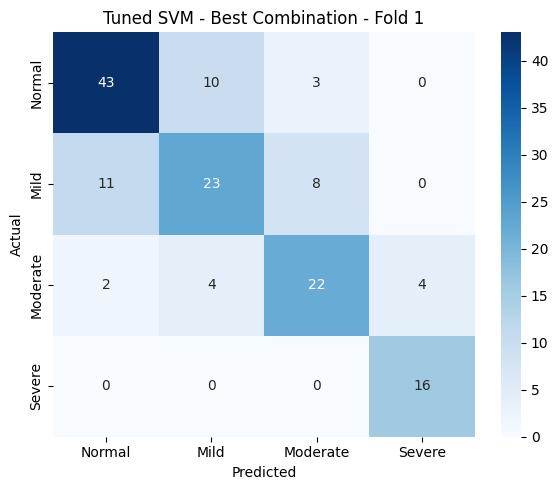

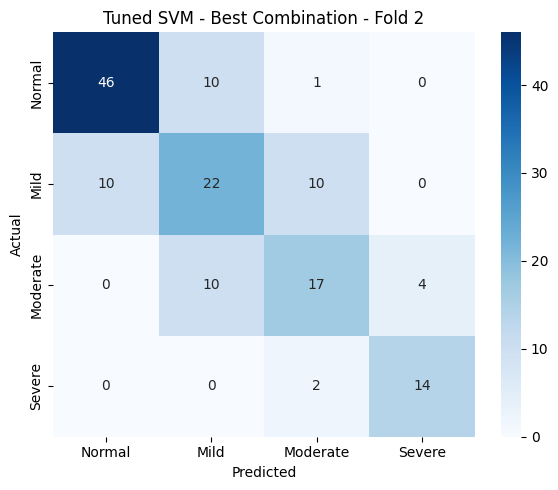

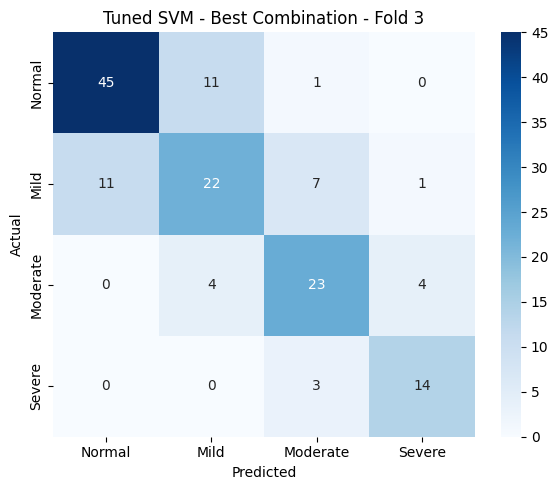

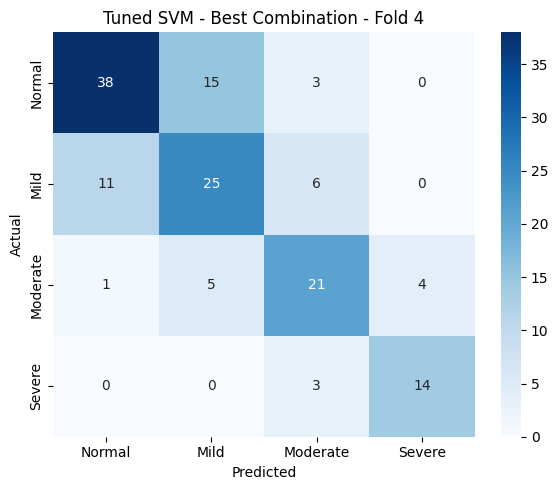

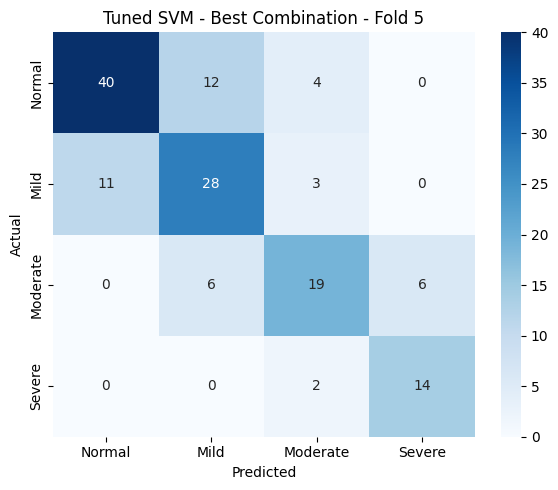


Aggregated Metrics Across All Folds
----------------------------------------------------------------------------------------------------


,Accuracy,Precision_macro,Recall_macro,F1_macro,MCC,AP_Severe
0,0.6941,0.6928,0.7145,0.7024,0.5723,0.8017



Aggregated Classification Report Across All Folds
----------------------------------------------------------------------------------------------------


,precision,recall,f1-score,support
Normal,0.7881,0.7518,0.7695,282.0000
Mild,0.5797,0.5742,0.5769,209.0000
Moderate,0.6456,0.6538,0.6497,156.0000
Severe,0.7579,0.8780,0.8136,82.0000
accuracy,0.6941,0.6941,0.6941,0.6941
macro avg,0.6928,0.7145,0.7024,729.0000
weighted avg,0.6945,0.6941,0.6936,729.0000



Aggregated Confusion Matrix


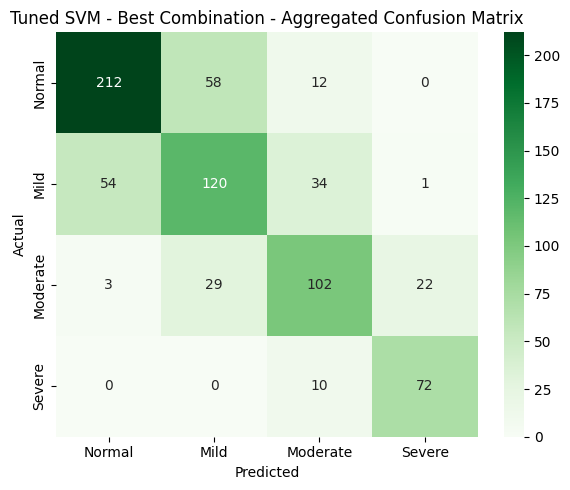

In [58]:
# Build the best parameter dictionary
best_model_params = {
    'C': float(best_combo_row['C']),
    'kernel': best_combo_row['kernel'],
    'gamma': best_combo_row['gamma'],
    'class_weight': 'balanced',
    'probability': True,
    'random_state': 42
}

# Run CV using the best hyperparameters
tuned_results, tuned_reports, tuned_aggregated_metrics, tuned_aggregated_report, tuned_cm = run_svm_stratified_cv(
    X=X_train_selected,
    y=y_train,
    experiment_name='Tuned SVM - Best Combination',
    model_params=best_model_params
)

In [59]:
comparison_df = pd.concat(
    [
        selected_feature_agg_metrics.rename(index={0: 'Baseline - Selected '}),
        tuned_aggregated_metrics.rename(index={0: 'Tuned -Selected'})
    ],
    axis=0
)

comparison_df

,Accuracy,Precision_macro,Recall_macro,F1_macro,MCC,AP_Severe
Baseline - Selected,0.6763,0.6722,0.6977,0.6830,0.5483,0.7845
Tuned -Selected,0.6941,0.6928,0.7145,0.7024,0.5723,0.8017


# Final SVM Model

## Reatrain on full training set

In [60]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Use the selected 3 features only
selected_features = [
    'MUAP Amplitude uV',
    'MUAP Ration ms',
    'MUAP Polyphasia Percent'
]

X_train_selected = X_train[selected_features].copy()
X_test_selected = X_test[selected_features].copy()

X_train_selected.columns = X_train_selected.columns.str.replace(' ', '_')
X_test_selected.columns = X_test_selected.columns.str.replace(' ', '_')


# Create scaler for the final model
final_scaler = StandardScaler()

# Fit scaler on the full training set, then transform training data
X_train_final_scaled = final_scaler.fit_transform(X_train_selected)

# Build the final SVM model using the best hyperparameters
final_svm_model = SVC(**best_model_params)

# Train the final model on the full training set
final_svm_model.fit(X_train_final_scaled, y_train)

print("Final SVM model has been trained on the full training set.")

Final SVM model has been trained on the full training set.


## Testing on Test Set

Test Set Metrics


,Accuracy,Precision_macro,Recall_macro,F1_macro,MCC,AP_Severe
0,0.6776,0.6767,0.7145,0.6903,0.5536,0.8151


Test Set Classification Report


,precision,recall,f1-score,support
Normal,0.7581,0.6620,0.7068,71.0000
Mild,0.5714,0.6038,0.5872,53.0000
Moderate,0.7105,0.6923,0.7013,39.0000
Severe,0.6667,0.9000,0.7660,20.0000
accuracy,0.6776,0.6776,0.6776,0.6776
macro avg,0.6767,0.7145,0.6903,183.0000
weighted avg,0.6839,0.6776,0.6774,183.0000


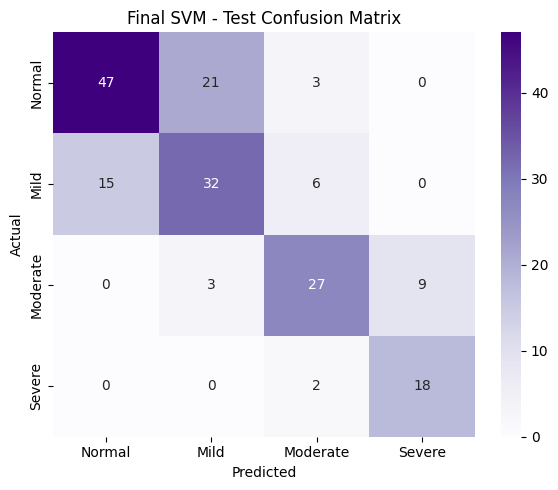

In [61]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, average_precision_score,
    classification_report, confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Transform the test set using the scaler fitted on training data
X_test_final_scaled = final_scaler.transform(X_test_selected)

# Predict labels and probabilities on the test set
y_test_pred = final_svm_model.predict(X_test_final_scaled)
y_test_proba = final_svm_model.predict_proba(X_test_final_scaled)

# Define class labels
class_names = ['Normal', 'Mild', 'Moderate', 'Severe']
class_labels = [0, 1, 2, 3]

# Severe class index
severe_label = 3
severe_index = class_labels.index(severe_label)

# Calculate test metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision_macro = precision_score(y_test, y_test_pred, average='macro', zero_division=0)
test_recall_macro = recall_score(y_test, y_test_pred, average='macro', zero_division=0)
test_f1_macro = f1_score(y_test, y_test_pred, average='macro', zero_division=0)
test_mcc = matthews_corrcoef(y_test, y_test_pred)

# Calculate AP for Severe class
y_test_severe = (y_test == severe_label).astype(int)
y_test_proba_severe = y_test_proba[:, severe_index]
test_ap_severe = average_precision_score(y_test_severe, y_test_proba_severe)

# Save metrics in a dataframe
test_metrics_df = pd.DataFrame([{
    'Accuracy': round(test_accuracy, 4),
    'Precision_macro': round(test_precision_macro, 4),
    'Recall_macro': round(test_recall_macro, 4),
    'F1_macro': round(test_f1_macro, 4),
    'MCC': round(test_mcc, 4),
    'AP_Severe': round(test_ap_severe, 4)
}])

print("Test Set Metrics")
display(test_metrics_df)

# Classification report
test_report_dict = classification_report(
    y_test,
    y_test_pred,
    labels=class_labels,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

test_report_df = pd.DataFrame(test_report_dict).transpose().round(4)

print("Test Set Classification Report")
display(test_report_df.loc[class_names + ['accuracy', 'macro avg', 'weighted avg']])

# Confusion matrix
test_cm = confusion_matrix(y_test, y_test_pred, labels=class_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(
    test_cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Final SVM - Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Explainable AI

In [62]:
import shap
import numpy as np
import pandas as pd

MODEL_FEATURES = [
    "MUAP_Amplitude_uV",
    "MUAP_Ration_ms",
    "MUAP_Polyphasia_Percent"
]

class_names = ["Normal", "Mild", "Moderate", "Severe"]

In [63]:
def svm_predict_proba_for_shap(X):
    # SHAP sometimes sends numpy arrays, so convert them to DataFrame
    if isinstance(X, np.ndarray):
        X = pd.DataFrame(X, columns=MODEL_FEATURES)

    X = X[MODEL_FEATURES].copy()

    # Apply the same scaler used during training
    X_scaled = final_scaler.transform(X)

    # Return class probabilities
    return final_svm_model.predict_proba(X_scaled)

In [64]:
background = shap.sample(X_train_selected, 50, random_state=42)

X_explain = X_test_selected.sample(50, random_state=42)

In [65]:
explainer = shap.KernelExplainer(
    svm_predict_proba_for_shap,
    background
)

shap_values = explainer.shap_values(X_explain)

  0%|          | 0/50 [00:00<?, ?it/s]

SHAP Summary Plot for: Normal


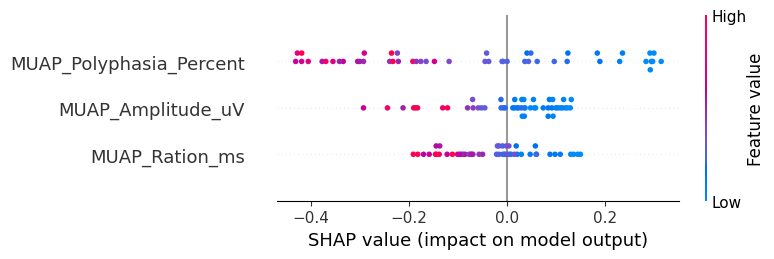

SHAP Summary Plot for: Mild


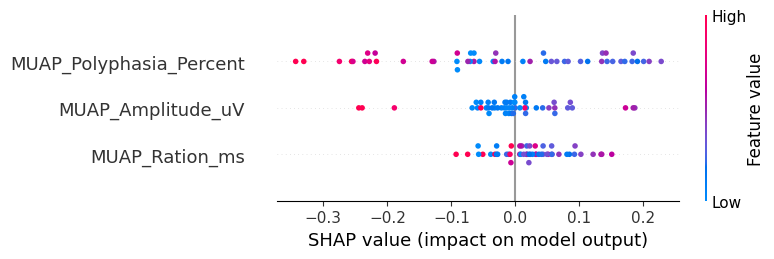

SHAP Summary Plot for: Moderate


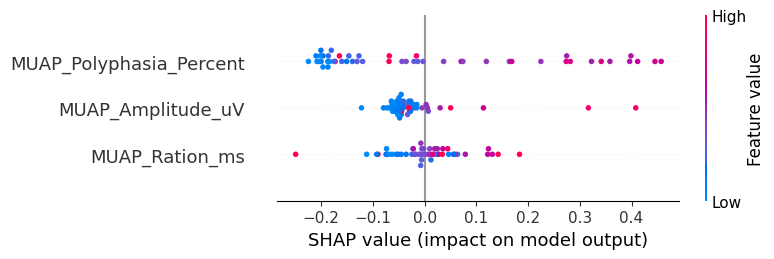

SHAP Summary Plot for: Severe


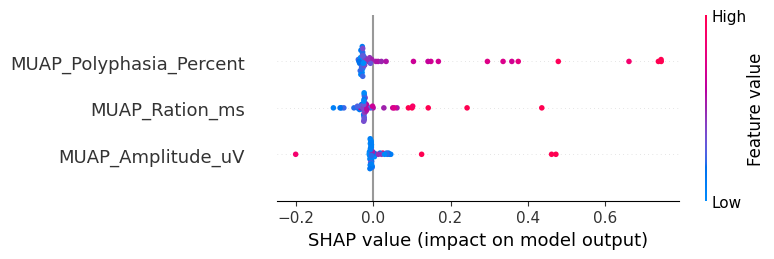

In [66]:
for i, class_name in enumerate(class_names):
    print("SHAP Summary Plot for:", class_name)

    shap.summary_plot(
        shap_values[:, :, i],
        X_explain,
        feature_names=X_explain.columns
    )

In [67]:
importance_all = []

for i, class_name in enumerate(class_names):
    importance = np.mean(np.abs(shap_values[:, :, i]), axis=0)
    importance_all.append(importance)

svm_shap_importance_df = pd.DataFrame(
    np.array(importance_all).T,
    columns=class_names,
    index=X_explain.columns
)

svm_shap_importance_df

,Normal,Mild,Moderate,Severe
MUAP_Amplitude_uV,0.083261,0.052151,0.057363,0.035199
MUAP_Ration_ms,0.075964,0.046826,0.050578,0.049862
MUAP_Polyphasia_Percent,0.216945,0.133624,0.186945,0.123836


# Overfitting check

In [68]:
# Extract tuned CV aggregated metrics as scalar values
best_cv_accuracy = tuned_aggregated_metrics.loc[0, 'Accuracy']
best_cv_precision_macro = tuned_aggregated_metrics.loc[0, 'Precision_macro']
best_cv_recall_macro = tuned_aggregated_metrics.loc[0, 'Recall_macro']
best_cv_f1_macro = tuned_aggregated_metrics.loc[0, 'F1_macro']
best_cv_mcc = tuned_aggregated_metrics.loc[0, 'MCC']
best_cv_ap_severe = tuned_aggregated_metrics.loc[0, 'AP_Severe']


# CV vs Test comparison table
cv_vs_test_df = pd.DataFrame([
    ['Train Set', best_cv_accuracy, best_cv_precision_macro, best_cv_recall_macro, best_cv_f1_macro, best_cv_mcc, best_cv_ap_severe],
    ['Test Set',      test_accuracy,   test_precision_macro,   test_recall_macro,   test_f1_macro,   test_mcc,   test_ap_severe]
], columns=['Dataset', 'Accuracy', 'Precision_macro', 'Recall_macro', 'F1_macro', 'MCC', 'AP_Severe'])

cv_vs_test_df.iloc[:, 1:] = cv_vs_test_df.iloc[:, 1:].round(4)

print("Train Set vs Test Set")
display(cv_vs_test_df)

Train Set vs Test Set


,Dataset,Accuracy,Precision_macro,Recall_macro,F1_macro,MCC,AP_Severe
0,Train Set,0.6941,0.6928,0.7145,0.7024,0.5723,0.8017
1,Test Set,0.6776,0.6767,0.7145,0.6903,0.5536,0.8151


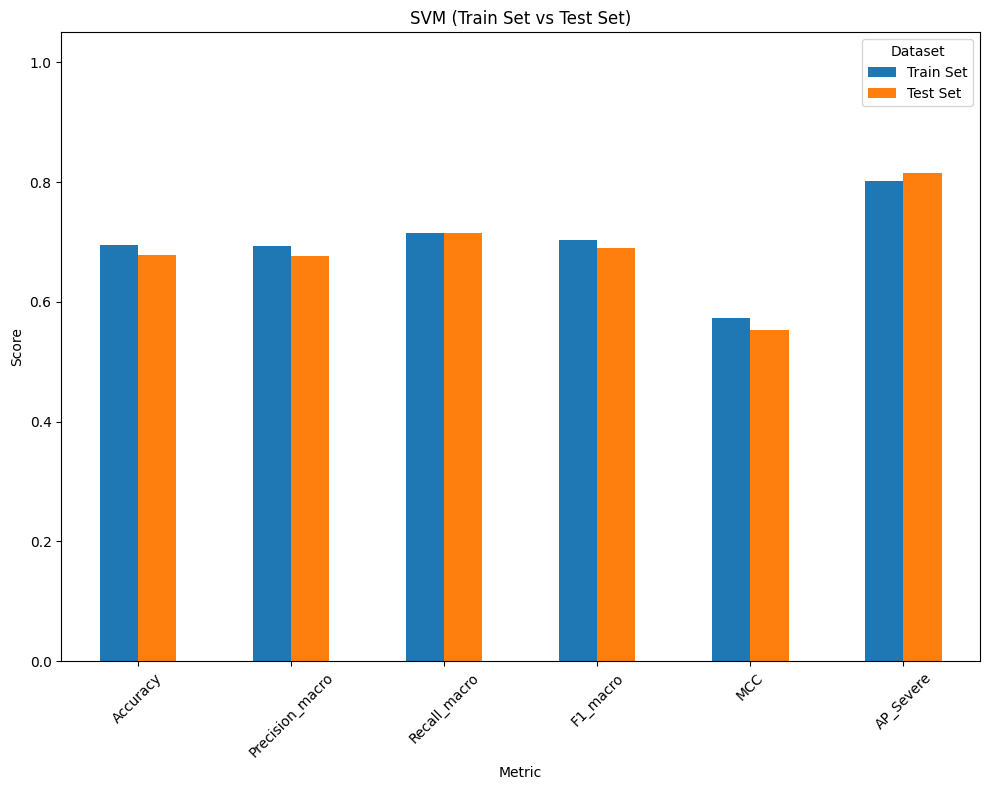

In [69]:
# Prepare data for plotting
plot_df = cv_vs_test_df.set_index('Dataset').T

# Plot comparison
plot_df.plot(kind='bar', figsize=(10, 8))
plt.title("SVM (Train Set vs Test Set)")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.xticks(rotation=45)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

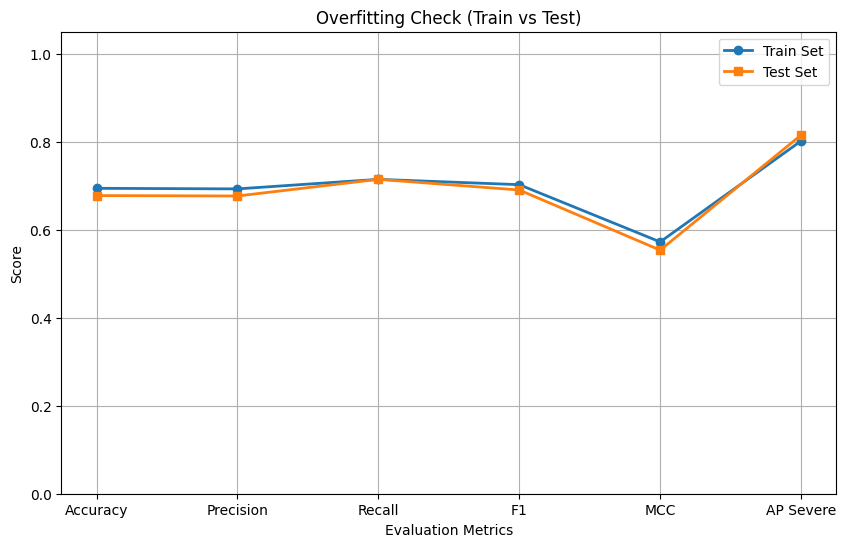

In [70]:
import matplotlib.pyplot as plt

metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'MCC', 'AP Severe']

cv_scores = [
    best_cv_accuracy,
    best_cv_precision_macro,
    best_cv_recall_macro,
    best_cv_f1_macro,
    best_cv_mcc,
    best_cv_ap_severe
]

test_scores = [
    test_accuracy,
    test_precision_macro,
    test_recall_macro,
    test_f1_macro,
    test_mcc,
    test_ap_severe
]

plt.figure(figsize=(10,6))

plt.plot(
    metrics,
    cv_scores,
    marker='o',
    linewidth=2,
    label='Train Set'
)

plt.plot(
    metrics,
    test_scores,
    marker='s',
    linewidth=2,
    label='Test Set'
)

plt.title('Overfitting Check (Train vs Test)')
plt.xlabel('Evaluation Metrics')
plt.ylabel('Score')
plt.ylim(0.0,1.05)

plt.legend()
plt.grid(True)

plt.show()

## Make Predactions

In [71]:
# Make predictions on the test set
sample_predictions = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_test_pred
}, index=y_test.index)

print("Sample Predictions from Test Set")
display(sample_predictions.head(10))

Sample Predictions from Test Set


,Actual,Predicted
515,2,3
872,0,0
224,0,0
648,3,3
862,1,1
486,0,0
208,1,0
830,0,1
630,0,1
530,3,2


In [72]:
label_names = {
    0: 'Normal',
    1: 'Mild',
    2: 'Moderate',
    3: 'Severe'
}

sample_predictions_named = pd.DataFrame({
    'Actual': y_test.map(label_names).values,
    'Predicted': pd.Series(y_test_pred, index=y_test.index).map(label_names).values
}, index=y_test.index)

print("Sample Predictions from Test Set (Class Names)")
display(sample_predictions_named.head(10))

Sample Predictions from Test Set (Class Names)


,Actual,Predicted
515,Moderate,Severe
872,Normal,Normal
224,Normal,Normal
648,Severe,Severe
862,Mild,Mild
486,Normal,Normal
208,Mild,Normal
830,Normal,Mild
630,Normal,Mild
530,Severe,Moderate


In [73]:
proba_df = pd.DataFrame(
    y_test_proba,
    columns=['Prob_Normal', 'Prob_Mild', 'Prob_Moderate', 'Prob_Severe'],
    index=y_test.index
)

prediction_with_proba = pd.concat([sample_predictions_named, proba_df], axis=1)

print("Predictions with Probabilities")
display(prediction_with_proba.head(10))

Predictions with Probabilities


,Actual,Predicted,Prob_Normal,Prob_Mild,Prob_Moderate,Prob_Severe
515,Moderate,Severe,0.005423,0.010239,0.278378,0.705960
872,Normal,Normal,0.702634,0.281648,0.015225,0.000493
224,Normal,Normal,0.638062,0.348876,0.011738,0.001324
648,Severe,Severe,0.002834,0.004686,0.137714,0.854766
862,Mild,Mild,0.297201,0.553550,0.147836,0.001412
486,Normal,Normal,0.625050,0.352322,0.022179,0.000449
208,Mild,Normal,0.779853,0.210326,0.008290,0.001531
830,Normal,Mild,0.170122,0.651873,0.176042,0.001963
630,Normal,Mild,0.374200,0.484535,0.138961,0.002304
530,Severe,Moderate,0.046223,0.135829,0.730709,0.087239


## Train on Full Dataset( Train + Test)

In [74]:
## Train on Full Dataset (Train + Test) - SVM Deployment Model

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import pandas as pd
import joblib

# Selected EMG features
selected_features = [
    'MUAP Amplitude uV',
    'MUAP Ration ms',
    'MUAP Polyphasia Percent'
]

# Combine train and test for the final deployment model
X_full_selected = pd.concat([
    X_train[selected_features],
    X_test[selected_features]
], axis=0)

y_full = pd.concat([y_train, y_test], axis=0)

# Reset index
X_full_selected = X_full_selected.reset_index(drop=True)
y_full = y_full.reset_index(drop=True)

print("Full dataset shape :", X_full_selected.shape)
print("Full target shape  :", y_full.shape)
print("Selected features  :", selected_features)

# Fit scaler on the full dataset
final_deployment_scaler = StandardScaler()

X_full_selected_scaled = pd.DataFrame(
    final_deployment_scaler.fit_transform(X_full_selected),
    columns=selected_features
)

print("Scaled full dataset shape :", X_full_selected_scaled.shape)
print("Final feature names       :", list(X_full_selected_scaled.columns))

# Build final deployment SVM model
final_deployment_svm_model = SVC(
    **best_model_params
)

# Train on the full dataset
final_deployment_svm_model.fit(X_full_selected_scaled, y_full)

print("Final deployment SVM model has been trained on the full dataset.")

# Save everything in one file
deployment_bundle = {
    'model': final_deployment_svm_model,
    'scaler': final_deployment_scaler,
    'selected_features': selected_features,
    'label_names': {
        0: 'Normal',
        1: 'Mild',
        2: 'Moderate',
        3: 'Severe'
    }
}

joblib.dump(deployment_bundle, 'final_svm_deployment_bundle.pkl')

print("Deployment bundle saved successfully.")

# Load the saved bundle
deployment_bundle = joblib.load('final_svm_deployment_bundle.pkl')

loaded_model = deployment_bundle['model']
loaded_scaler = deployment_bundle['scaler']
loaded_selected_features = deployment_bundle['selected_features']
loaded_label_names = deployment_bundle['label_names']

print("Bundle loaded successfully.")

Full dataset shape : (912, 3)
Full target shape  : (912,)
Selected features  : ['MUAP Amplitude uV', 'MUAP Ration ms', 'MUAP Polyphasia Percent']
Scaled full dataset shape : (912, 3)
Final feature names       : ['MUAP Amplitude uV', 'MUAP Ration ms', 'MUAP Polyphasia Percent']
Final deployment SVM model has been trained on the full dataset.
Deployment bundle saved successfully.
Bundle loaded successfully.


# New sample prediction

In [75]:
# New unseen sample
new_sample = pd.DataFrame([{
    'MUAP_Amplitude_uV': 450,
    'MUAP_Ration_ms': 12,
    'MUAP_Polyphasia_Percent': 35

}])

# Scale using the saved/fitted scaler
new_sample_scaled = final_scaler.transform(new_sample)

# Predict class
new_prediction = final_svm_model.predict(new_sample_scaled)[0]

# Predict probabilities
new_prediction_proba = final_svm_model.predict_proba(new_sample_scaled)[0]

label_names = {
    0: 'Normal',
    1: 'Mild',
    2: 'Moderate',
    3: 'Severe'
}

print("Predicted class:", label_names[new_prediction])
print("Prediction probabilities:")
print(f"Normal   : {new_prediction_proba[0]:.4f}")
print(f"Mild     : {new_prediction_proba[1]:.4f}")
print(f"Moderate : {new_prediction_proba[2]:.4f}")
print(f"Severe   : {new_prediction_proba[3]:.4f}")

Predicted class: Moderate
Prediction probabilities:
Normal   : 0.0273
Mild     : 0.0784
Moderate : 0.7342
Severe   : 0.1601
